<a href="https://colab.research.google.com/github/parisatugnaitug2023-debug/IQF_Midterm1/blob/main/IQF_Final_COVID_19_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm

tickers = ["^NSEI", "ONGC.NS", "WIPRO.NS", "BHARTIARTL.NS", "TCS.NS", "COALINDIA.NS", "POWERGRID.NS", "SUNPHARMA.NS", "CIPLA.NS", "GRASIM.NS", "HDFCLIFE.NS", "ITC.NS", "HINDALCO.NS", "APOLLOHOSP.NS", "NTPC.NS", "NESTLEIND.NS", "INFY.NS", "ULTRACEMCO.NS", "KOTAKBANK.NS", "TATACONSUM.NS", "SBILIFE.NS", "TITAN.NS", "AXISBANK.NS", "DRREDDY.NS", "HCLTECH.NS", "TECHM.NS", "BAJAJ-AUTO.NS", "ICICIBANK.NS", "TATASTEEL.NS", "BEL.NS", "TRENT.NS", "LT.NS", "JSWSTEEL.NS", "MARUTI.NS", "ADANIPORTS.NS", "ASIANPAINT.NS", "EICHERMOT.NS", "HINDUNILVR.NS", "BAJAJFINSV.NS", "HDFCBANK.NS", "ADANIENT.NS", "SBIN.NS", "BAJFINANCE.NS", "INDIGO.NS", "RELIANCE.NS", "SHRIRAMFIN.NS"]

data = yf.download(tickers, start="2019-01-01", end="2024-01-01")["Close"]

# Compute log returns
returns = np.log(data / data.shift(1)).dropna()
market = returns["^NSEI"]
stocks = returns.drop(columns=["^NSEI"])

# Market volatility (30-day rolling)
market_vol = market.rolling(window=30).var()

# Save
returns.to_csv("returns.csv")
market_vol.to_csv("market_vol.csv")
# =====================================================
# COVID DATASET
# =====================================================

covid_returns = pd.read_csv(
    "returns.csv",
    index_col=0
)

# Convert index to datetime
covid_returns.index = pd.to_datetime(covid_returns.index)

# =====================================================
# MARKET + STOCKS
# =====================================================

covid_market = covid_returns["^NSEI"]

covid_stocks = covid_returns.drop(columns=["^NSEI"])

/tmp/ipykernel_14758/2259411467.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2019-01-01", end="2024-01-01")["Close"]
[*********************100%***********************]  46 of 46 completed


In [48]:
# =========================
# FULL DATASET DOWNLOAD
# =========================

import yfinance as yf
import pandas as pd

tickers = ["^NSEI", "ONGC.NS", "WIPRO.NS", "BHARTIARTL.NS", "TCS.NS", "COALINDIA.NS", "POWERGRID.NS", "SUNPHARMA.NS", "CIPLA.NS", "GRASIM.NS", "HDFCLIFE.NS", "ITC.NS", "HINDALCO.NS", "APOLLOHOSP.NS", "NTPC.NS", "NESTLEIND.NS", "INFY.NS", "ULTRACEMCO.NS", "KOTAKBANK.NS", "TATACONSUM.NS", "SBILIFE.NS", "TITAN.NS", "AXISBANK.NS", "DRREDDY.NS", "HCLTECH.NS", "TECHM.NS", "BAJAJ-AUTO.NS", "ICICIBANK.NS", "TATASTEEL.NS", "BEL.NS", "TRENT.NS", "LT.NS", "JSWSTEEL.NS", "MARUTI.NS", "ADANIPORTS.NS", "ASIANPAINT.NS", "EICHERMOT.NS", "HINDUNILVR.NS", "BAJAJFINSV.NS", "HDFCBANK.NS", "ADANIENT.NS", "SBIN.NS", "BAJFINANCE.NS", "INDIGO.NS", "RELIANCE.NS", "SHRIRAMFIN.NS"]

# Download adjusted close prices
data = yf.download(
    tickers,
    start="2007-09-17",
    end="2024-01-01"
)["Close"]

# =========================
# CHECK DATA AVAILABILITY
# =========================

availability = pd.DataFrame({
    "Missing": data.isna().sum(),
    "Available %": 100 * (1 - data.isna().mean())
})

print(availability.sort_values("Available %", ascending=False))

# =========================
# KEEP STOCKS WITH >=95% DATA
# =========================

threshold = 0.95

valid_stocks = data.columns[data.notna().mean() >= threshold]

data = data[valid_stocks]

# =========================
# SEE FINAL STOCK LIST
# =========================

print("Final stocks retained:")
print(data.columns.tolist())

print("\nNumber of stocks retained:")
print(len(data.columns))

# =========================
# SAVE CLEAN DATASET
# =========================

data.to_excel("full_sample.xlsx")

/tmp/ipykernel_14758/3135923293.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  46 of 46 completed


               Missing  Available %
Ticker                             
HCLTECH.NS           0   100.000000
ADANIENT.NS          1    99.975100
AXISBANK.NS          1    99.975100
ASIANPAINT.NS        1    99.975100
BAJAJ-AUTO.NS        1    99.975100
APOLLOHOSP.NS        1    99.975100
CIPLA.NS             1    99.975100
BAJFINANCE.NS        1    99.975100
BEL.NS               1    99.975100
BHARTIARTL.NS        1    99.975100
EICHERMOT.NS         1    99.975100
DRREDDY.NS           1    99.975100
GRASIM.NS            1    99.975100
BAJAJFINSV.NS        1    99.975100
TRENT.NS             1    99.975100
ULTRACEMCO.NS        1    99.975100
HDFCBANK.NS          1    99.975100
HINDALCO.NS          1    99.975100
ICICIBANK.NS         1    99.975100
HINDUNILVR.NS        1    99.975100
ITC.NS               1    99.975100
INFY.NS              1    99.975100
LT.NS                1    99.975100
MARUTI.NS            1    99.975100
JSWSTEEL.NS          1    99.975100
KOTAKBANK.NS         1    99

In [49]:
# =====================================================
# GLOBAL FINANCIAL CRISIS DATASET
# Period: Sep 2007 – Jul 2009
# =====================================================

import yfinance as yf
import pandas as pd
import numpy as np

# =====================================================
# TICKERS
# =====================================================

gfc_tickers = [
    "^NSEI",

    # Energy / Utilities
    "ABB.NS",
    "BPCL.NS",
    "GAIL.NS",
    "NTPC.NS",
    "ONGC.NS",
    "POWERGRID.NS",
    "RELIANCE.NS",
    "RELINFRA.NS",
    "RPOWER.NS",
    "SUZLON.NS",

    # IT
    "WIPRO.NS",
    "TCS.NS",
    "HCLTECH.NS",
    "INFY.NS",

    # Financials
    "AXISBANK.NS",
    "HDFCBANK.NS",
    "HDFC.NS",
    "ICICIBANK.NS",
    "IDFC.NS",
    "PNB.NS",
    "RELCAPITAL.NS",
    "SBIN.NS",

    # Telecom
    "BHARTIARTL.NS",
    "IDEA.NS",
    "RCOM.NS",

    # Pharma
    "CIPLA.NS",
    "RANBAXY.NS",
    "SUNPHARMA.NS",

    # Cement / Materials
    "ACC.NS",
    "AMBUJACEM.NS",
    "GRASIM.NS",
    "ULTRACEMCO.NS",

    # Metals
    "HINDALCO.NS",
    "JINDALSTEL.NS",
    "SAIL.NS",
    "TATASTEEL.NS",
    "STER.NS",

    # Industrials / Infra
    "BHEL.NS",
    "DLF.NS",
    "JPASSOCIAT.NS",
    "LT.NS",
    "SIEMENS.NS",
    "UNITECH.NS",

    # Auto
    "HEROMOTOCO.NS",
    "M&M.NS",
    "MARUTI.NS",
    "TATAMOTORS.NS",

    # FMCG / Consumer
    "HINDUNILVR.NS",
    "ITC.NS",

    # Others
    "CAIRN.NS"
]

# =====================================================
# DOWNLOAD DATA
# =====================================================

gfc_data = yf.download(
    gfc_tickers,
    start="2007-09-17",
    end="2009-07-31"
)["Close"]

# =====================================================
# CHECK DATA AVAILABILITY
# =====================================================

availability = pd.DataFrame({
    "Missing": gfc_data.isna().sum(),
    "Available %": 100 * (1 - gfc_data.isna().mean())
})

print("===================================")
print("DATA AVAILABILITY")
print("===================================")

print(
    availability.sort_values(
        "Available %",
        ascending=False
    )
)

# =====================================================
# CHECK FAILED TICKERS
# =====================================================

failed = gfc_data.columns[gfc_data.isna().all()]

print("\n===================================")
print("FAILED TICKERS")
print("===================================")

print(failed.tolist())

# =====================================================
# REMOVE FAILED TICKERS
# =====================================================

gfc_data = gfc_data.drop(columns=failed)

# =====================================================
# KEEP STOCKS WITH >=95% DATA
# =====================================================

threshold = 0.95

valid_stocks = gfc_data.columns[
    gfc_data.notna().mean() >= threshold
]

gfc_data = gfc_data[valid_stocks]

# =====================================================
# FINAL STOCK LIST
# =====================================================

print("\n===================================")
print("FINAL STOCKS RETAINED")
print("===================================")

print(gfc_data.columns.tolist())

print("\nNumber of stocks retained:")

print(len(gfc_data.columns))

# =====================================================
# SAVE CLEAN DATASET
# =====================================================

gfc_data.to_excel("financial_crisis_dataset.xlsx")

print("\nDataset saved successfully.")

# =====================================================
# COMPUTE RETURNS
# =====================================================

gfc_returns = np.log(
    gfc_data / gfc_data.shift(1)
).dropna()

# =====================================================
# SEPARATE MARKET + STOCKS
# =====================================================

gfc_market = gfc_returns["^NSEI"]

gfc_stocks = gfc_returns.drop(columns=["^NSEI"])

print("\nReturns successfully computed.")

# =====================================================
# OPTIONAL:
# SAVE RETURNS FILE
# =====================================================

gfc_returns.to_excel("financial_crisis_returns.xlsx")

print("Returns file saved successfully.")

/tmp/ipykernel_14758/3356917269.py:94: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gfc_data = yf.download(
[*********************100%***********************]  51 of 51 completed
ERROR:yfinance:
6 Failed downloads:
ERROR:yfinance:['CAIRN.NS', 'STER.NS', 'RANBAXY.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2007-09-17 -> 2009-07-31)')
ERROR:yfinance:['TATAMOTORS.NS', 'IDFC.NS', 'HDFC.NS']: YFTzMissingError('possibly delisted; no timezone found')


DATA AVAILABILITY
               Missing  Available %
Ticker                             
ABB.NS               0   100.000000
ACC.NS               0   100.000000
AMBUJACEM.NS         0   100.000000
AXISBANK.NS          0   100.000000
BHARTIARTL.NS        0   100.000000
BHEL.NS              0   100.000000
BPCL.NS              0   100.000000
CIPLA.NS             0   100.000000
DLF.NS               0   100.000000
GAIL.NS              0   100.000000
GRASIM.NS            0   100.000000
HINDUNILVR.NS        0   100.000000
HCLTECH.NS           0   100.000000
HDFCBANK.NS          0   100.000000
HEROMOTOCO.NS        0   100.000000
ICICIBANK.NS         0   100.000000
HINDALCO.NS          0   100.000000
INFY.NS              0   100.000000
IDEA.NS              0   100.000000
WIPRO.NS             0   100.000000
UNITECH.NS           0   100.000000
ITC.NS               0   100.000000
JINDALSTEL.NS        0   100.000000
LT.NS                0   100.000000
JPASSOCIAT.NS        0   100.000000
M&M.NS    

In [50]:
# =====================================================
# TAPER TANTRUM DATASET
# Period: Oct 2012 – Mar 2014
# =====================================================

import yfinance as yf
import pandas as pd
import numpy as np

# =====================================================
# TICKERS
# =====================================================

taper_tickers = [
    "^NSEI",

    "ACC.NS",
    "AMBUJACEM.NS",
    "ASIANPAINT.NS",
    "AXISBANK.NS",
    "BAJAJ-AUTO.NS",
    "BANKBARODA.NS",
    "BHARTIARTL.NS",
    "BHEL.NS",
    "BPCL.NS",
    "CAIRN.NS",
    "CIPLA.NS",
    "COALINDIA.NS",
    "DLF.NS",
    "DRREDDY.NS",
    "GAIL.NS",
    "GRASIM.NS",
    "HCLTECH.NS",
    "HDFC.NS",
    "HDFCBANK.NS",
    "HEROMOTOCO.NS",
    "HINDALCO.NS",
    "HINDUNILVR.NS",
    "ICICIBANK.NS",
    "IDFC.NS",
    "INDUSINDBK.NS",
    "INFY.NS",
    "ITC.NS",
    "JINDALSTEL.NS",
    "KOTAKBANK.NS",
    "LT.NS",
    "LUPIN.NS",
    "M&M.NS",
    "MARUTI.NS",
    "UNITDSPR.NS",
    "NMDC.NS",
    "NTPC.NS",
    "ONGC.NS",
    "PNB.NS",
    "POWERGRID.NS",
    "RELIANCE.NS",
    "SBIN.NS",
    "VEDL.NS",          # Sesa Sterlite
    "SUNPHARMA.NS",
    "TATAMOTORS.NS",
    "TATAPOWER.NS",
    "TATASTEEL.NS",
    "TCS.NS",
    "TECHM.NS",
    "ULTRACEMCO.NS",
    "WIPRO.NS"
]
# =====================================================
# DOWNLOAD DATA
# =====================================================

taper_data = yf.download(
    taper_tickers,
    start="2012-10-01",
    end="2014-03-31"
)["Close"]
# =====================================================
# CHECK DATA AVAILABILITY
# =====================================================

availability = pd.DataFrame({
    "Missing": taper_data.isna().sum(),
    "Available %": 100 * (1 - taper_data.isna().mean())
})

print("===================================")
print("DATA AVAILABILITY")
print("===================================")

print(
    availability.sort_values(
        "Available %",
        ascending=False
    )
)

# =====================================================
# CHECK FAILED TICKERS
# =====================================================

failed = taper_data.columns[taper_data.isna().all()]

print("\n===================================")
print("FAILED TICKERS")
print("===================================")

print(failed.tolist())

# =====================================================
# REMOVE FAILED TICKERS
# =====================================================

taper_data = taper_data.drop(columns=failed)

# =====================================================
# KEEP STOCKS WITH >=95% DATA
# =====================================================

threshold = 0.95

valid_stocks = taper_data.columns[
    taper_data.notna().mean() >= threshold
]

taper_data = taper_data[valid_stocks]

# =====================================================
# FINAL STOCK LIST
# =====================================================

print("\n===================================")
print("FINAL STOCKS RETAINED")
print("===================================")

print(taper_data.columns.tolist())

print("\nNumber of stocks retained:")

print(len(taper_data.columns))

# =====================================================
# SAVE CLEAN DATASET
# =====================================================

taper_data.to_excel("taper_tantrum_dataset.xlsx")

print("\nDataset saved successfully.")

# =====================================================
# COMPUTE LOG RETURNS
# =====================================================

taper_returns = np.log(
    taper_data / taper_data.shift(1)
).dropna()

# =====================================================
# SEPARATE MARKET + STOCKS
# =====================================================

taper_market = taper_returns["^NSEI"]

taper_stocks = taper_returns.drop(columns=["^NSEI"])

print("\nReturns successfully computed.")

# =====================================================
# SAVE RETURNS FILE
# =====================================================

taper_returns.to_excel("taper_tantrum_returns.xlsx")

print("Returns file saved successfully.")

/tmp/ipykernel_14758/4291522126.py:72: FutureWarning: YF.download() has changed argument auto_adjust default to True
  taper_data = yf.download(
[*********************100%***********************]  51 of 51 completed
ERROR:yfinance:
5 Failed downloads:
ERROR:yfinance:['CAIRN.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2012-10-01 -> 2014-03-31)')
ERROR:yfinance:['UNITDSPR.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2012-10-01 -> 2014-03-31) (Yahoo error = "Data doesn\'t exist for startDate = 1349029800, endDate = 1396204200")')
ERROR:yfinance:['TATAMOTORS.NS', 'IDFC.NS', 'HDFC.NS']: YFTzMissingError('possibly delisted; no timezone found')


DATA AVAILABILITY
               Missing  Available %
Ticker                             
ACC.NS               0   100.000000
AMBUJACEM.NS         0   100.000000
ASIANPAINT.NS        0   100.000000
AXISBANK.NS          0   100.000000
BAJAJ-AUTO.NS        0   100.000000
BANKBARODA.NS        0   100.000000
BHARTIARTL.NS        0   100.000000
BHEL.NS              0   100.000000
BPCL.NS              0   100.000000
CIPLA.NS             0   100.000000
COALINDIA.NS         0   100.000000
GRASIM.NS            0   100.000000
DLF.NS               0   100.000000
DRREDDY.NS           0   100.000000
GAIL.NS              0   100.000000
HDFCBANK.NS          0   100.000000
HCLTECH.NS           0   100.000000
HINDALCO.NS          0   100.000000
HEROMOTOCO.NS        0   100.000000
VEDL.NS              0   100.000000
PNB.NS               0   100.000000
HINDUNILVR.NS        0   100.000000
ICICIBANK.NS         0   100.000000
INDUSINDBK.NS        0   100.000000
INFY.NS              0   100.000000
ITC.NS    

In [51]:
import pandas as pd
import numpy as np

# ==========================================
# LOAD RF DATA
# ==========================================

rf = pd.read_excel("rf_rates.xlsx")

# Convert date column
rf["Date"] = pd.to_datetime(rf["Date"])

# Set index
rf = rf.set_index("Date")

# ==========================================
# CONVERT % TO DECIMAL
# ==========================================

rf["rf_annual"] = rf["Rate"] / 100

# ==========================================
# CONVERT ANNUAL RATE TO DAILY RATE
# ==========================================

rf["rf_daily"] = (1 + rf["rf_annual"])**(1/252) - 1

# ==========================================
# CREATE DAILY DATE INDEX
# ==========================================

daily_index = pd.date_range(
    start="2007-01-01",
    end="2024-01-01",
    freq="B"   # business days
)

rf_daily = rf.reindex(daily_index)

# ==========================================
# FORWARD FILL MONTHLY VALUES
# ==========================================

rf_daily = rf_daily.ffill()

# ==========================================
# KEEP ONLY DAILY RF COLUMN
# ==========================================

rf_daily = rf_daily[["rf_daily"]]

# Rename column
rf_daily.columns = ["rf"]

# ==========================================
# SAVE CLEAN RF DATASET
# ==========================================

rf_daily.to_excel("rf_daily_clean.xlsx")

print(rf_daily.head())

                  rf
2007-01-01  0.000193
2007-01-02  0.000193
2007-01-03  0.000193
2007-01-04  0.000193
2007-01-05  0.000193


In [52]:
#OVERALL SECTOR MAP
sector_map = {

    # =========================
    # ENERGY
    # =========================
    "RELIANCE.NS": "Energy",
    "ONGC.NS": "Energy",
    "BPCL.NS": "Energy",
    "GAIL.NS": "Energy",

    # =========================
    # IT
    # =========================
    "INFY.NS": "IT",
    "TCS.NS": "IT",
    "WIPRO.NS": "IT",
    "HCLTECH.NS": "IT",
    "TECHM.NS": "IT",

    # =========================
    # FINANCIALS
    # =========================
    "HDFCBANK.NS": "Financials",
    "ICICIBANK.NS": "Financials",
    "KOTAKBANK.NS": "Financials",
    "SBIN.NS": "Financials",
    "AXISBANK.NS": "Financials",
    "PNB.NS": "Financials",

    # =========================
    # PHARMA
    # =========================
    "SUNPHARMA.NS": "Pharma",
    "CIPLA.NS": "Pharma",
    "DRREDDY.NS": "Pharma",
    "LUPIN.NS": "Pharma",

    # =========================
    # FMCG / CONSUMER
    # =========================
    "HINDUNILVR.NS": "FMCG",
    "ITC.NS": "FMCG",
    "ASIANPAINT.NS": "FMCG",

    # =========================
    # AUTO
    # =========================
    "MARUTI.NS": "Auto",
    "BAJAJ-AUTO.NS": "Auto",
    "HEROMOTOCO.NS": "Auto",
    "M&M.NS": "Auto",

    # =========================
    # CEMENT
    # =========================
    "ULTRACEMCO.NS": "Cement",
    "GRASIM.NS": "Cement",
    "ACC.NS": "Cement",
    "AMBUJACEM.NS": "Cement",

    # =========================
    # METALS
    # =========================
    "TATASTEEL.NS": "Metals",
    "HINDALCO.NS": "Metals",
    "JINDALSTEL.NS": "Metals",

    # =========================
    # INFRA / INDUSTRIALS
    # =========================
    "LT.NS": "Infra",
    "DLF.NS": "Infra",
    "BHEL.NS": "Infra",

    # =========================
    # UTILITIES
    # =========================
    "NTPC.NS": "Utilities",
    "POWERGRID.NS": "Utilities",
    "TATAPOWER.NS": "Utilities"
}

In [53]:
#financial crises sector map
gfc_sector_map = {

    # =========================
    # ENERGY
    # =========================
    "RELIANCE.NS": "Energy",
    "ONGC.NS": "Energy",
    "BPCL.NS": "Energy",
    "GAIL.NS": "Energy",

    # =========================
    # IT
    # =========================
    "INFY.NS": "IT",
    "TCS.NS": "IT",
    "WIPRO.NS": "IT",
    "HCLTECH.NS": "IT",

    # =========================
    # FINANCIALS
    # =========================
    "HDFCBANK.NS": "Financials",
    "ICICIBANK.NS": "Financials",
    "AXISBANK.NS": "Financials",
    "SBIN.NS": "Financials",
    "PNB.NS": "Financials",
    "RELCAPITAL.NS": "Financials",

    # =========================
    # PHARMA
    # =========================
    "SUNPHARMA.NS": "Pharma",
    "CIPLA.NS": "Pharma",

    # =========================
    # FMCG
    # =========================
    "HINDUNILVR.NS": "FMCG",
    "ITC.NS": "FMCG",

    # =========================
    # AUTO
    # =========================
    "MARUTI.NS": "Auto",
    "HEROMOTOCO.NS": "Auto",
    "M&M.NS": "Auto",

    # =========================
    # CEMENT
    # =========================
    "ULTRACEMCO.NS": "Cement",
    "GRASIM.NS": "Cement",
    "ACC.NS": "Cement",
    "AMBUJACEM.NS": "Cement",

    # =========================
    # METALS
    # =========================
    "TATASTEEL.NS": "Metals",
    "HINDALCO.NS": "Metals",
    "JINDALSTEL.NS": "Metals",
    "SAIL.NS": "Metals",

    # =========================
    # INFRA / INDUSTRIALS
    # =========================
    "LT.NS": "Infra",
    "DLF.NS": "Infra",
    "BHEL.NS": "Infra",
    "JPASSOCIAT.NS": "Infra",
    "RELINFRA.NS": "Infra",
    "UNITECH.NS": "Infra",
    "SIEMENS.NS": "Infra",

    # =========================
    # UTILITIES
    # =========================
    "NTPC.NS": "Utilities",
    "POWERGRID.NS": "Utilities",
    "SUZLON.NS": "Utilities",

    # =========================
    # TELECOM
    # =========================
    "BHARTIARTL.NS": "Telecom",
    "IDEA.NS": "Telecom",
    "RCOM.NS": "Telecom",

    # =========================
    # CAPITAL GOODS / INDUSTRIAL
    # =========================
    "ABB.NS": "Industrial"
}

In [8]:
taper_sector_map = {

    # =========================
    # ENERGY
    # =========================
    "RELIANCE.NS": "Energy",
    "ONGC.NS": "Energy",
    "BPCL.NS": "Energy",
    "GAIL.NS": "Energy",
    "COALINDIA.NS": "Energy",

    # =========================
    # IT
    # =========================
    "INFY.NS": "IT",
    "TCS.NS": "IT",
    "WIPRO.NS": "IT",
    "HCLTECH.NS": "IT",
    "TECHM.NS": "IT",

    # =========================
    # FINANCIALS
    # =========================
    "HDFCBANK.NS": "Financials",
    "ICICIBANK.NS": "Financials",
    "AXISBANK.NS": "Financials",
    "SBIN.NS": "Financials",
    "KOTAKBANK.NS": "Financials",
    "PNB.NS": "Financials",
    "BANKBARODA.NS": "Financials",
    "INDUSINDBK.NS": "Financials",

    # =========================
    # PHARMA
    # =========================
    "SUNPHARMA.NS": "Pharma",
    "CIPLA.NS": "Pharma",
    "DRREDDY.NS": "Pharma",
    "LUPIN.NS": "Pharma",

    # =========================
    # FMCG / CONSUMER
    # =========================
    "HINDUNILVR.NS": "FMCG",
    "ITC.NS": "FMCG",
    "ASIANPAINT.NS": "FMCG",

    # =========================
    # AUTO
    # =========================
    "MARUTI.NS": "Auto",
    "BAJAJ-AUTO.NS": "Auto",
    "HEROMOTOCO.NS": "Auto",
    "M&M.NS": "Auto",

    # =========================
    # CEMENT
    # =========================
    "ULTRACEMCO.NS": "Cement",
    "GRASIM.NS": "Cement",
    "ACC.NS": "Cement",
    "AMBUJACEM.NS": "Cement",

    # =========================
    # METALS / MINING
    # =========================
    "TATASTEEL.NS": "Metals",
    "HINDALCO.NS": "Metals",
    "JINDALSTEL.NS": "Metals",
    "NMDC.NS": "Metals",
    "VEDL.NS": "Metals",

    # =========================
    # INFRA / INDUSTRIALS
    # =========================
    "LT.NS": "Infra",
    "DLF.NS": "Infra",
    "BHEL.NS": "Infra",

    # =========================
    # UTILITIES
    # =========================
    "NTPC.NS": "Utilities",
    "POWERGRID.NS": "Utilities",
    "TATAPOWER.NS": "Utilities",

    # =========================
    # TELECOM
    # =========================
    "BHARTIARTL.NS": "Telecom"
}

In [54]:
# Ensure datetime indexes
gfc_market.index = pd.to_datetime(gfc_market.index)

gfc_stocks.index = pd.to_datetime(gfc_stocks.index)

rf_daily.index = pd.to_datetime(rf_daily.index)

# Force business-day frequency
rf_daily = rf_daily.asfreq('B')

# Forward fill missing RF values
rf_daily = rf_daily.ffill()

In [63]:
# =====================================================
# FULL SAMPLE DATASET
# =====================================================

full_returns = pd.read_excel(
    "full_sample.xlsx",
    index_col=0
)

# Convert index to datetime
full_returns.index = pd.to_datetime(full_returns.index)

# =====================================================
# MARKET + STOCKS
# =====================================================

full_market = full_returns["^NSEI"]

full_stocks = full_returns.drop(columns=["^NSEI"])

In [55]:
# =====================================================
# MAIN ANALYSIS FUNCTION
# =====================================================

def run_analysis(start, end, market, stocks, rf_clean, sector_map):

    import pandas as pd
    import statsmodels.api as sm

    # =================================================
    # 1. SLICE DATA
    # =================================================

    market_sub = market.loc[start:end]
    stocks_sub = stocks.loc[start:end]
    rf_sub = rf_clean.loc[start:end]

    # =================================================
    # 2. ALIGN MARKET + RF
    # =================================================

    aligned = pd.concat([market_sub, rf_sub], axis=1).dropna()
    print("Aligned shape:", aligned.shape)

    print(aligned.head())

    aligned.columns = ["market", "rf"]

    market_excess = aligned["market"] - aligned["rf"]

    # Align stock dates
    stocks_sub = stocks_sub.loc[aligned.index]

    # =================================================
    # 3. COMPUTE EXCESS RETURNS
    # =================================================

    excess_returns = stocks_sub.subtract(
        aligned["rf"],
        axis=0
    )

    # =================================================
    # 4. CAPM RESIDUALS
    # =================================================

    residuals = pd.DataFrame(index=market_excess.index)

    for stock in excess_returns.columns:

        X = sm.add_constant(market_excess)

        y = excess_returns[stock]

        model = sm.OLS(y, X).fit()

        residuals[stock] = model.resid

    # =================================================
    # 5. IDIOSYNCRATIC RISK
    # =================================================

    idio_risk = residuals.rolling(30).var()

    avg_idio = idio_risk.mean(axis=1)

    # =================================================
    # 6. SECTOR-WISE IDIOSYNCRATIC RISK
    # =================================================

    sector_idio = pd.DataFrame(index=idio_risk.index)

    for sector in set(sector_map.values()):

        sector_stocks = [

            s for s in idio_risk.columns

            if sector_map.get(s) == sector
        ]

        # Keep only stocks actually present
        sector_stocks = [

            s for s in sector_stocks

            if s in idio_risk.columns
        ]

        if len(sector_stocks) > 0:

            sector_idio[sector] = idio_risk[
                sector_stocks
            ].mean(axis=1)

    # =================================================
    # 7. MARKET VOLATILITY
    # =================================================

    market_vol = market_excess.rolling(30).var()

    # =================================================
    # 8. REGRESSION 1
    # IDIOSYNCRATIC RISK vs MARKET VOL
    # =================================================

    reg1 = pd.concat(
        [avg_idio, market_vol],
        axis=1
    ).dropna()

    print("Reg1 shape:", reg1.shape)

    reg1.columns = [
        "idio_risk",
        "market_vol"
    ]

    model1 = sm.OLS(

        reg1["idio_risk"],

        sm.add_constant(
            reg1["market_vol"]
        )

    ).fit(

        cov_type='HAC',

        cov_kwds={'maxlags': 3}
    )

    # =================================================
    # 9. REGRESSION 2
    # PERSISTENCE OF IDIOSYNCRATIC RISK
    # =================================================

    lagged = avg_idio.shift(1)

    reg2 = pd.concat(
        [avg_idio, lagged],
        axis=1
    ).dropna()

    print("Reg2 shape:", reg2.shape)

    reg2.columns = [
        "idio_risk",
        "lagged"
    ]

    model2 = sm.OLS(

        reg2["idio_risk"],

        sm.add_constant(
            reg2["lagged"]
        )

    ).fit(

        cov_type='HAC',

        cov_kwds={'maxlags': 3}
    )

    # =================================================
    # PRINT RESULTS
    # =================================================

    print("\n===================================")
    print("REGRESSION 1")
    print("IDIO RISK vs MARKET VOL")
    print("===================================")

    print(model1.summary())

    print("\n===================================")
    print("REGRESSION 2")
    print("PERSISTENCE")
    print("===================================")

    print(model2.summary())

    # =================================================
    # RETURN OUTPUTS
    # =================================================

    return (
        model1,
        model2,
        sector_idio,
        reg1,
        reg2,
        residuals
    )

In [58]:
#running each period
#covid
m1_covid, m2_covid, sector_covid, reg1_covid, reg2_covid, residuals_covid = run_analysis(

    "2020-02-01",
    "2020-07-31",

    covid_market,
    covid_stocks,
    rf_daily,
    sector_map
)

Aligned shape: (122, 2)
               ^NSEI       rf
2020-02-03 -0.021479  0.00006
2020-02-04  0.022946  0.00006
2020-02-05  0.009099  0.00006
2020-02-06  0.004029  0.00006
2020-02-07 -0.003268  0.00006
Reg1 shape: (93, 2)
Reg2 shape: (92, 2)

REGRESSION 1
IDIO RISK vs MARKET VOL
                            OLS Regression Results                            
Dep. Variable:              idio_risk   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     359.7
Date:                Tue, 12 May 2026   Prob (F-statistic):           2.26e-33
Time:                        09:30:40   Log-Likelihood:                 723.77
No. Observations:                  93   AIC:                            -1444.
Df Residuals:                      91   BIC:                            -1438.
Df Model:                           1                                         
Covaria

In [59]:
m1_gfc, m2_gfc, sector_gfc, reg1_gfc, reg2_gfc, residuals_gfc = run_analysis(

    "2007-09-17",
    "2009-07-31",

    gfc_market,
    gfc_stocks,
    rf_daily,
    gfc_sector_map
)

Aligned shape: (440, 2)
               ^NSEI        rf
2007-10-08 -0.019619  0.000152
2007-10-09  0.046520  0.000152
2007-10-10  0.021210  0.000152
2007-10-11  0.015211  0.000152
2007-10-12 -0.017639  0.000152
Reg1 shape: (411, 2)
Reg2 shape: (410, 2)

REGRESSION 1
IDIO RISK vs MARKET VOL
                            OLS Regression Results                            
Dep. Variable:              idio_risk   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     1087.
Date:                Tue, 12 May 2026   Prob (F-statistic):          3.02e-117
Time:                        09:30:43   Log-Likelihood:                 3089.0
No. Observations:                 411   AIC:                            -6174.
Df Residuals:                     409   BIC:                            -6166.
Df Model:                           1                                         

In [60]:
m1_taper, m2_taper, sector_taper, reg1_taper, reg2_taper, residuals_taper = run_analysis(

    "2012-10-01",
    "2014-03-31",

    taper_market,
    taper_stocks,
    rf_daily,
    taper_sector_map
)

Aligned shape: (361, 2)
               ^NSEI        rf
2012-10-03  0.002175  0.000004
2012-10-04  0.009784  0.000004
2012-10-05 -0.007048  0.000004
2012-10-08 -0.012423  0.000004
2012-10-09  0.005026  0.000004
Reg1 shape: (332, 2)
Reg2 shape: (331, 2)

REGRESSION 1
IDIO RISK vs MARKET VOL
                            OLS Regression Results                            
Dep. Variable:              idio_risk   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     200.0
Date:                Tue, 12 May 2026   Prob (F-statistic):           7.88e-36
Time:                        09:30:47   Log-Likelihood:                 2732.1
No. Observations:                 332   AIC:                            -5460.
Df Residuals:                     330   BIC:                            -5453.
Df Model:                           1                                         

In [64]:
m1_full, m2_full, sector_full, reg1_full, reg2_full, residuals_full = run_analysis(

    "2007-09-17",
    "2024-01-01",

    full_market,
    full_stocks,
    rf_daily,
    sector_map
)

Aligned shape: (3992, 2)
                  ^NSEI        rf
2007-09-17  4494.649902  0.000163
2007-09-18  4546.200195  0.000163
2007-09-19  4732.350098  0.000163
2007-09-20  4747.549805  0.000163
2007-09-21  4837.549805  0.000163
Reg1 shape: (3963, 2)
Reg2 shape: (3962, 2)

REGRESSION 1
IDIO RISK vs MARKET VOL
                            OLS Regression Results                            
Dep. Variable:              idio_risk   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     31.54
Date:                Tue, 12 May 2026   Prob (F-statistic):           2.08e-08
Time:                        09:36:50   Log-Likelihood:                -36952.
No. Observations:                3963   AIC:                         7.391e+04
Df Residuals:                    3961   BIC:                         7.392e+04
Df Model:                           1                    

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:              idio_risk   No. Observations:                 3963
Model:               MarkovRegression   Log Likelihood              -51287.228
Date:                Tue, 12 May 2026   AIC                         102586.456
Time:                        09:48:14   BIC                         102624.165
Sample:                             0   HQIC                        102599.829
                               - 3963                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.792e+04    909.717     74.664      0.000    6.61e+04    6.97e+04
sigma2      1.455e+09      0.302   4.82e+09      0.0

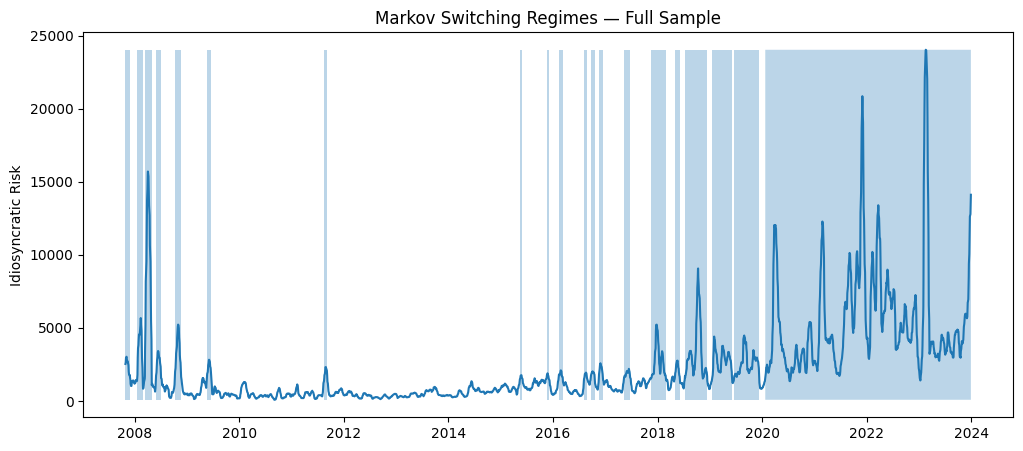

In [75]:
# =====================================================
# MARKOV SWITCHING — FULL SAMPLE
# =====================================================

from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import matplotlib.pyplot as plt

def detect_regimes(series):

    series = series.ffill()

    series = series * 100

    model = MarkovRegression(

        series,

        k_regimes=2,

        trend='c',

        switching_variance=True
    )

    res = model.fit()

    probs = res.smoothed_marginal_probabilities[1]

    regime = (probs > 0.5).astype(int)

    return res, regime, probs


# =====================================================
# RUN MODEL
# =====================================================

res_full, regime_full, probs_full = detect_regimes(

    reg1_full["idio_risk"]

)

# =====================================================
# SUMMARY
# =====================================================

print(res_full.summary())

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(12,5))

plt.plot(probs_full.index, reg1_full["idio_risk"].reindex(probs_full.index))


plt.fill_between(

    reg1_full.index,

    reg1_full["idio_risk"].min(),

    reg1_full["idio_risk"].max(),

    where=(regime_full == 1),

    alpha=0.3
)

plt.title("Markov Switching Regimes — Full Sample")

plt.ylabel("Idiosyncratic Risk")

plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:              idio_risk   No. Observations:                   93
Model:               MarkovRegression   Log Likelihood                 261.832
Date:                Tue, 12 May 2026   AIC                           -511.664
Time:                        09:48:21   BIC                           -496.468
Sample:                             0   HQIC                          -505.528
                                 - 93                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0452      0.002     27.446      0.000       0.042       0.048
sigma2      6.417e-05   2.14e-05      2.995      0.0

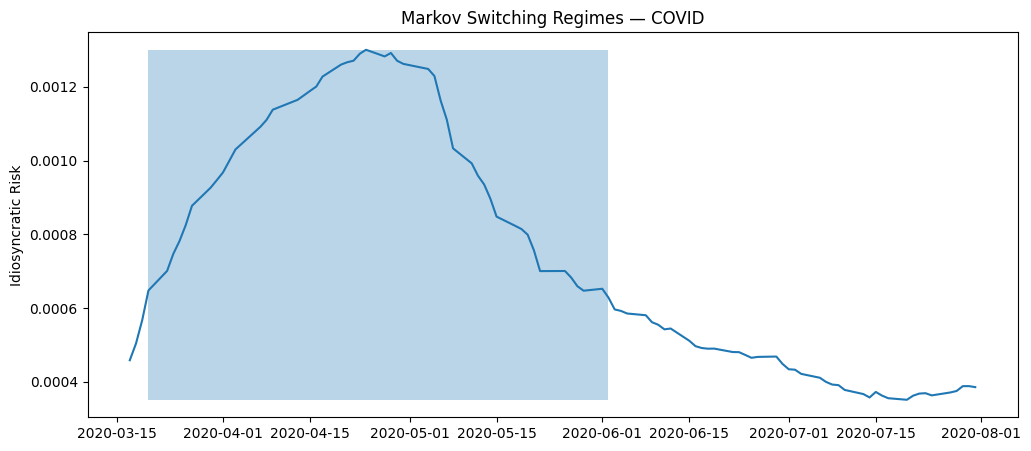

In [76]:
# =====================================================
# MARKOV SWITCHING — COVID
# =====================================================

res_covid, regime_covid, probs_covid = detect_regimes(

    reg1_covid["idio_risk"]

)

# =====================================================
# SUMMARY
# =====================================================

print(res_covid.summary())

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(12,5))

plt.plot(

    reg1_covid.index,

    reg1_covid["idio_risk"]

)

plt.fill_between(

    reg1_covid.index,

    reg1_covid["idio_risk"].min(),

    reg1_covid["idio_risk"].max(),

    where=(regime_covid == 1),

    alpha=0.3
)

plt.title("Markov Switching Regimes — COVID")

plt.ylabel("Idiosyncratic Risk")

plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:              idio_risk   No. Observations:                  411
Model:               MarkovRegression   Log Likelihood                1056.080
Date:                Tue, 12 May 2026   AIC                          -2100.160
Time:                        09:48:26   BIC                          -2076.049
Sample:                             0   HQIC                         -2090.622
                                - 411                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0576      0.001     70.066      0.000       0.056       0.059
sigma2         0.0001    1.3e-05      9.918      0.0

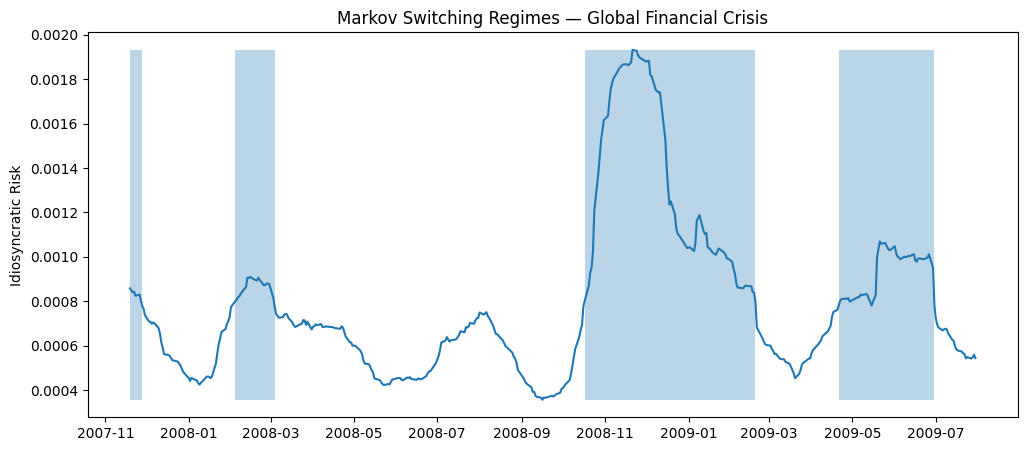

In [77]:
# =====================================================
# MARKOV SWITCHING — GLOBAL FINANCIAL CRISIS
# =====================================================

res_gfc, regime_gfc, probs_gfc = detect_regimes(

    reg1_gfc["idio_risk"]

)

# =====================================================
# SUMMARY
# =====================================================

print(res_gfc.summary())

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(12,5))

plt.plot(

    reg1_gfc.index,

    reg1_gfc["idio_risk"]

)

plt.fill_between(

    reg1_gfc.index,

    reg1_gfc["idio_risk"].min(),

    reg1_gfc["idio_risk"].max(),

    where=(regime_gfc == 1),

    alpha=0.3
)

plt.title("Markov Switching Regimes — Global Financial Crisis")

plt.ylabel("Idiosyncratic Risk")

plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:              idio_risk   No. Observations:                  332
Model:               MarkovRegression   Log Likelihood                1074.099
Date:                Tue, 12 May 2026   AIC                          -2136.199
Time:                        09:48:32   BIC                          -2113.368
Sample:                             0   HQIC                         -2127.094
                                - 332                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0157      0.000    118.812      0.000       0.015       0.016
sigma2      6.745e-07   2.37e-08     28.437      0.0

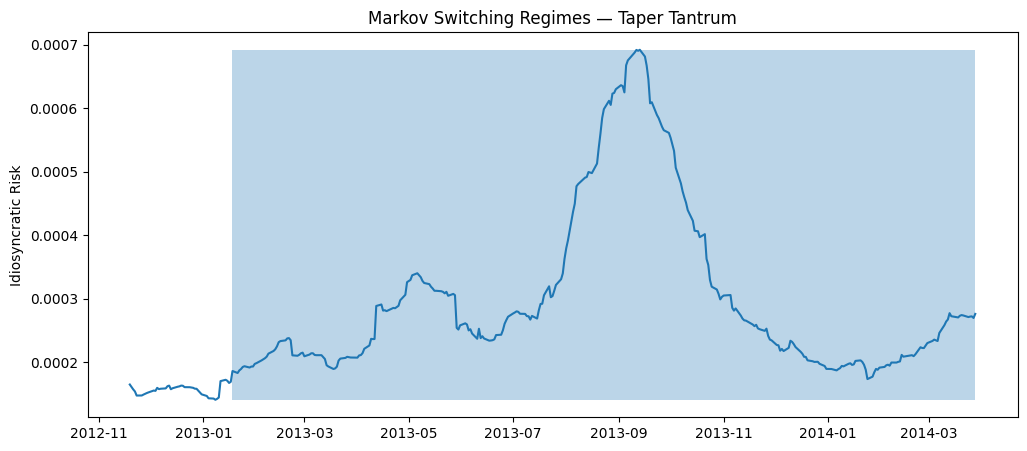

In [78]:
# =====================================================
# MARKOV SWITCHING — TAPER TANTRUM
# =====================================================

res_taper, regime_taper, probs_taper = detect_regimes(

    reg1_taper["idio_risk"]

)

# =====================================================
# SUMMARY
# =====================================================

print(res_taper.summary())

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(12,5))

plt.plot(

    reg1_taper.index,

    reg1_taper["idio_risk"]

)

plt.fill_between(

    reg1_taper.index,

    reg1_taper["idio_risk"].min(),

    reg1_taper["idio_risk"].max(),

    where=(regime_taper == 1),

    alpha=0.3
)

plt.title("Markov Switching Regimes — Taper Tantrum")

plt.ylabel("Idiosyncratic Risk")

plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



===== AR(1) Results: Full Sample =====
                            AutoReg Model Results                             
Dep. Variable:              idio_risk   No. Observations:                 3962
Model:                     AutoReg(1)   Log Likelihood              -27501.416
Method:               Conditional MLE   S.D. of innovations            250.663
Date:                Tue, 12 May 2026   AIC                          55008.831
Time:                        09:55:54   BIC                          55027.684
Sample:                             1   HQIC                         55015.517
                                 3962                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.4859      5.030      1.289      0.197      -3.373      16.345
idio_risk.L1     0.9984      0.001    748.414      0.000       0.996       1.001
    

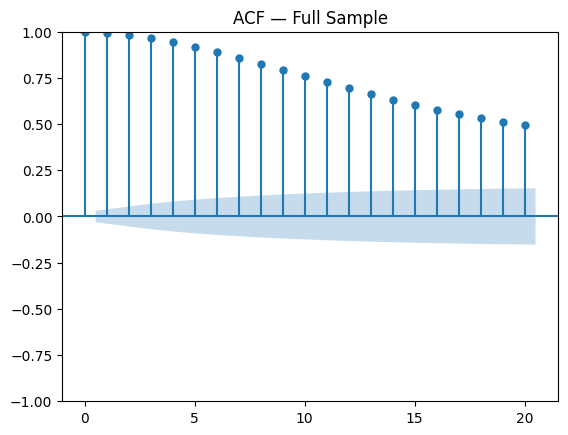

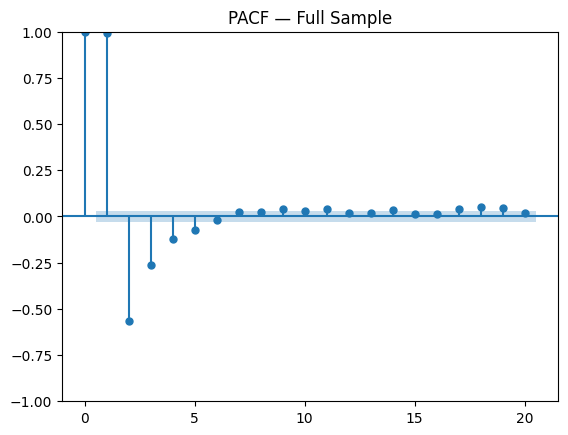

In [80]:
# =====================================================
# AR(1) + ACF/PACF — FULL SAMPLE
# =====================================================

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# =====================================================
# AR(1) FUNCTION
# =====================================================

def run_ar1(series, label):

    series = series.dropna()

    model = AutoReg(
        series,
        lags=1
    ).fit()

    print(f"\n===== AR(1) Results: {label} =====")

    print(model.summary())

    return model

# =====================================================
# RUN AR(1)
# =====================================================

ar1_full = run_ar1(

    reg2_full["idio_risk"],

    "Full Sample"
)

# =====================================================
# ACF
# =====================================================

plot_acf(

    reg2_full["idio_risk"].dropna(),

    lags=20
)

plt.title("ACF — Full Sample")

plt.show()

# =====================================================
# PACF
# =====================================================

plot_pacf(

    reg2_full["idio_risk"].dropna(),

    lags=20
)

plt.title("PACF — Full Sample")

plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



===== AR(1) Results: COVID =====
                            AutoReg Model Results                             
Dep. Variable:              idio_risk   No. Observations:                   92
Model:                     AutoReg(1)   Log Likelihood                 824.551
Method:               Conditional MLE   S.D. of innovations              0.000
Date:                Tue, 12 May 2026   AIC                          -1643.101
Time:                        09:56:10   BIC                          -1635.568
Sample:                             1   HQIC                         -1640.062
                                   92                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.105e-06   7.35e-06     -0.150      0.880   -1.55e-05    1.33e-05
idio_risk.L1     0.9997      0.009    107.960      0.000       0.982       1.018
          

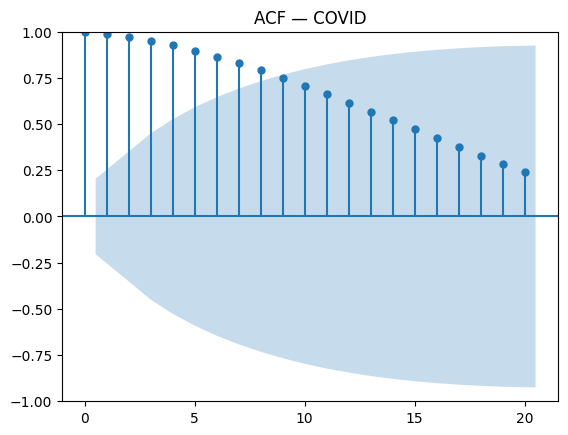

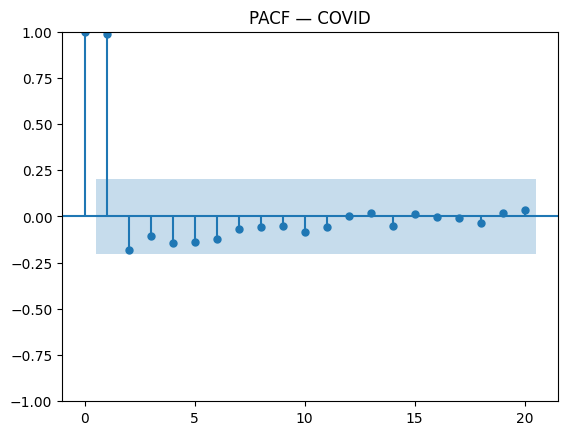

In [81]:
# =====================================================
# AR(1) + ACF/PACF — COVID
# =====================================================

ar1_covid = run_ar1(

    reg2_covid["idio_risk"],

    "COVID"
)

# =====================================================
# ACF
# =====================================================

plot_acf(

    reg2_covid["idio_risk"].dropna(),

    lags=20
)

plt.title("ACF — COVID")

plt.show()

# =====================================================
# PACF
# =====================================================

plot_pacf(

    reg2_covid["idio_risk"].dropna(),

    lags=20
)

plt.title("PACF — COVID")

plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



===== AR(1) Results: Global Financial Crisis =====
                            AutoReg Model Results                             
Dep. Variable:              idio_risk   No. Observations:                  410
Model:                     AutoReg(1)   Log Likelihood                3656.878
Method:               Conditional MLE   S.D. of innovations              0.000
Date:                Tue, 12 May 2026   AIC                          -7307.756
Time:                        09:56:25   BIC                          -7295.715
Sample:                             1   HQIC                         -7302.992
                                  410                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2.065e-06   3.83e-06      0.540      0.589   -5.43e-06    9.56e-06
idio_risk.L1     0.9964      0.004    222.507      0.000       0.988     

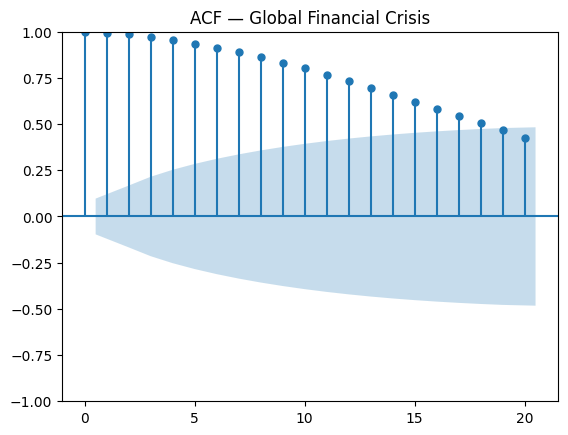

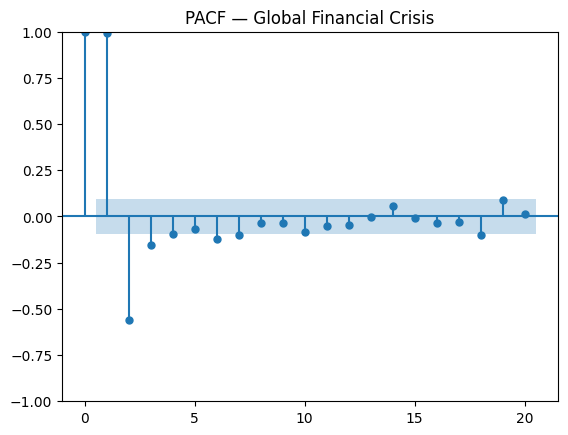

In [82]:
# =====================================================
# AR(1) + ACF/PACF — GLOBAL FINANCIAL CRISIS
# =====================================================

ar1_gfc = run_ar1(

    reg2_gfc["idio_risk"],

    "Global Financial Crisis"
)

# =====================================================
# ACF
# =====================================================

plot_acf(

    reg2_gfc["idio_risk"].dropna(),

    lags=20
)

plt.title("ACF — Global Financial Crisis")

plt.show()

# =====================================================
# PACF
# =====================================================

plot_pacf(

    reg2_gfc["idio_risk"].dropna(),

    lags=20
)

plt.title("PACF — Global Financial Crisis")

plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



===== AR(1) Results: Taper Tantrum =====
                            AutoReg Model Results                             
Dep. Variable:              idio_risk   No. Observations:                  331
Model:                     AutoReg(1)   Log Likelihood                3340.856
Method:               Conditional MLE   S.D. of innovations              0.000
Date:                Tue, 12 May 2026   AIC                          -6675.713
Time:                        09:57:10   BIC                          -6664.315
Sample:                             1   HQIC                         -6671.166
                                  331                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.504e-06   1.27e-06      1.181      0.238   -9.92e-07       4e-06
idio_risk.L1     0.9959      0.004    243.923      0.000       0.988       1.004
  

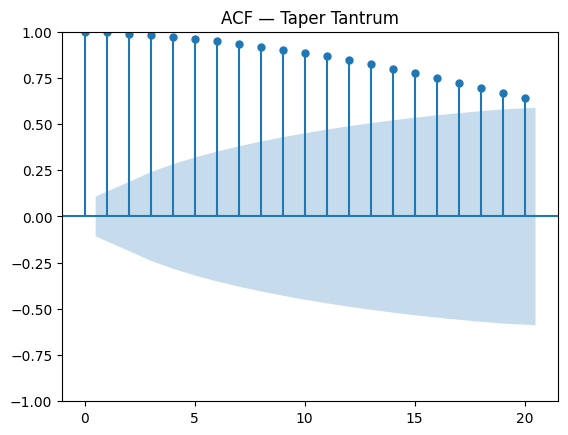

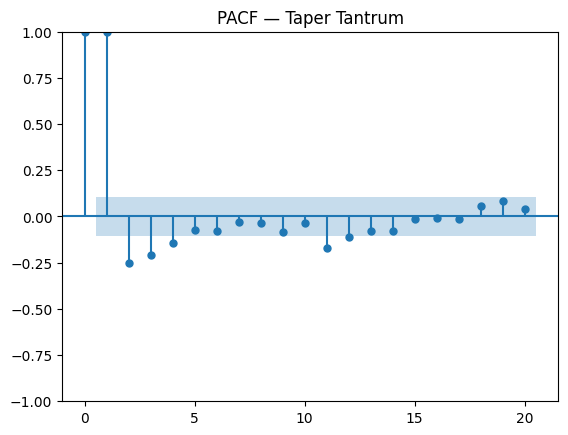

In [83]:
# =====================================================
# AR(1) + ACF/PACF — TAPER TANTRUM
# =====================================================

ar1_taper = run_ar1(

    reg2_taper["idio_risk"],

    "Taper Tantrum"
)

# =====================================================
# ACF
# =====================================================

plot_acf(

    reg2_taper["idio_risk"].dropna(),

    lags=20
)

plt.title("ACF — Taper Tantrum")

plt.show()

# =====================================================
# PACF
# =====================================================

plot_pacf(

    reg2_taper["idio_risk"].dropna(),

    lags=20
)

plt.title("PACF — Taper Tantrum")

plt.show()

In [ ]:
#OLD RESULTS DONT EDIT/RERUN
print("PRE - Regression 1")
print(m1_pre.summary())

print("PRE - Regression 2")
print(m2_pre.summary())

PRE - Regression 1
                            OLS Regression Results                            
Dep. Variable:              idio_risk   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                 0.0005168
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.982
Time:                        21:05:30   Log-Likelihood:                 756.65
No. Observations:                  85   AIC:                            -1509.
Df Residuals:                      83   BIC:                            -1504.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003   1.19e-05 

In [84]:
#OLD RESULTS DONT EDIT/RERUN
print("CRISIS - Regression 1")
print(m1_crisis.summary())

print("CRISIS - Regression 2")
print(m2_crisis.summary())

CRISIS - Regression 1
                            OLS Regression Results                            
Dep. Variable:              idio_risk   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     359.7
Date:                Tue, 12 May 2026   Prob (F-statistic):           2.27e-33
Time:                        09:58:07   Log-Likelihood:                 723.77
No. Observations:                  93   AIC:                            -1444.
Df Residuals:                      91   BIC:                            -1438.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004   2.16e-

In [ ]:
#OLD RESULTS DONT EDIT/RERUN
print("POST - Regression 1")
print(m1_post.summary())

print("POST - Regression 2")
print(m2_post.summary())

POST - Regression 1
                            OLS Regression Results                            
Dep. Variable:              idio_risk   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     23.06
Date:                Mon, 04 May 2026   Prob (F-statistic):           6.15e-06
Time:                        21:05:36   Log-Likelihood:                 718.06
No. Observations:                  93   AIC:                            -1432.
Df Residuals:                      91   BIC:                            -1427.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.716e-05   3.08e-05

In [85]:
#GARCH - testing volatility clustering
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 19.5 MB/s eta 0:00:00


In [86]:
# =====================================================
# GARCH(1,1) MODEL
# =====================================================

from arch import arch_model

def run_garch(series, label):

    # Remove missing values
    series = series.dropna()

    # Mild scaling for convergence
    series = series * 100

    # GARCH(1,1)
    model = arch_model(

        series,

        vol='Garch',

        p=1,

        q=1
    )

    # Fit model
    res = model.fit(disp='off')

    # =================================================
    # OUTPUT
    # =================================================

    print(f"\n===== GARCH Results: {label} =====")

    print(res.summary())

    # =================================================
    # EXTRACT PARAMETERS
    # =================================================

    alpha = res.params['alpha[1]']

    beta = res.params['beta[1]']

    persistence = alpha + beta

    # =================================================
    # INTERPRETATION OUTPUT
    # =================================================

    print("\nAlpha:", alpha)

    print(
        "→ impact of new shocks on volatility"
    )

    print("\nBeta:", beta)

    print(
        "→ persistence of past volatility"
    )

    print("\nPersistence (alpha + beta):", persistence)

    print(
        "→ overall volatility clustering"
    )

    return res

In [87]:
# =====================================================
# GARCH — FULL SAMPLE
# =====================================================

garch_full = run_garch(

    reg1_full["idio_risk"],

    "Full Sample"
)


===== GARCH Results: Full Sample =====
                     Constant Mean - GARCH Model Results                      
Dep. Variable:              idio_risk   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -50842.4
Distribution:                  Normal   AIC:                           101693.
Method:            Maximum Likelihood   BIC:                           101718.
                                        No. Observations:                 3963
Date:                Tue, May 12 2026   Df Residuals:                     3962
Time:                        10:01:29   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         6.7780e

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 8.943e+10. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.0001 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [88]:
# =====================================================
# GARCH — COVID
# =====================================================

garch_covid = run_garch(

    reg1_covid["idio_risk"],

    "COVID"
)


===== GARCH Results: COVID =====
                     Constant Mean - GARCH Model Results                      
Dep. Variable:              idio_risk   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                221.480
Distribution:                  Normal   AIC:                          -434.960
Method:            Maximum Likelihood   BIC:                          -424.829
                                        No. Observations:                   93
Date:                Tue, May 12 2026   Df Residuals:                       92
Time:                        10:01:39   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0480  3

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.00101. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [89]:
# =====================================================
# GARCH — GLOBAL FINANCIAL CRISIS
# =====================================================

garch_gfc = run_garch(

    reg1_gfc["idio_risk"],

    "Global Financial Crisis"
)


===== GARCH Results: Global Financial Crisis =====
                     Constant Mean - GARCH Model Results                      
Dep. Variable:              idio_risk   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                1041.63
Distribution:                  Normal   AIC:                          -2075.25
Method:            Maximum Likelihood   BIC:                          -2059.18
                                        No. Observations:                  411
Date:                Tue, May 12 2026   Df Residuals:                      410
Time:                        10:01:49   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu    

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001219. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [90]:
# =====================================================
# GARCH — TAPER TANTRUM
# =====================================================

garch_taper = run_garch(

    reg1_taper["idio_risk"],

    "Taper Tantrum"
)


===== GARCH Results: Taper Tantrum =====
                     Constant Mean - GARCH Model Results                      
Dep. Variable:              idio_risk   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                1018.17
Distribution:                  Normal   AIC:                          -2028.34
Method:            Maximum Likelihood   BIC:                          -2013.11
                                        No. Observations:                  332
Date:                Tue, May 12 2026   Df Residuals:                      331
Time:                        10:02:02   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001706. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [ ]:
#GARCH - testing volatility clustering
from arch import arch_model

def run_garch(series, label):
    series = series.dropna() * 100  # scale helps convergence

    model = arch_model(series, vol='Garch', p=1, q=1)
    res = model.fit(disp='off')

    print(f"\n===== GARCH Results: {label} =====")
    print(res.summary())

    return res

In [91]:
# =====================================================
# ROLLING CO-MOVEMENT REGRESSION
# =====================================================

import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def rolling_regression(avg_idio, market_vol, window=60):

    rolling_beta = []

    dates = []

    for i in range(window, len(avg_idio)):

        # Rolling sample
        y = avg_idio.iloc[i-window:i]

        x = market_vol.iloc[i-window:i]

        # Regression
        model = sm.OLS(

            y,

            sm.add_constant(x)

        ).fit()

        # Store beta
        rolling_beta.append(

            model.params.iloc[1]
        )

        dates.append(avg_idio.index[i])

    return pd.Series(

        rolling_beta,

        index=dates
    )


# =====================================================
# DIVERSIFICATION BREAKDOWN
# =====================================================

def rolling_diversification_breakdown(

    residuals,

    window=30
):

    avg_corrs = []

    dates = []

    for i in range(window, len(residuals)):

        # Rolling residual window
        sub = residuals.iloc[i-window:i]

        # Correlation matrix
        corr_matrix = sub.corr()

        # Average pairwise correlation
        avg_corr = corr_matrix.values[
            np.triu_indices_from(
                corr_matrix.values,
                k=1
            )
        ].mean()

        avg_corrs.append(avg_corr)

        dates.append(residuals.index[i])

    return pd.Series(

        avg_corrs,

        index=dates
    )

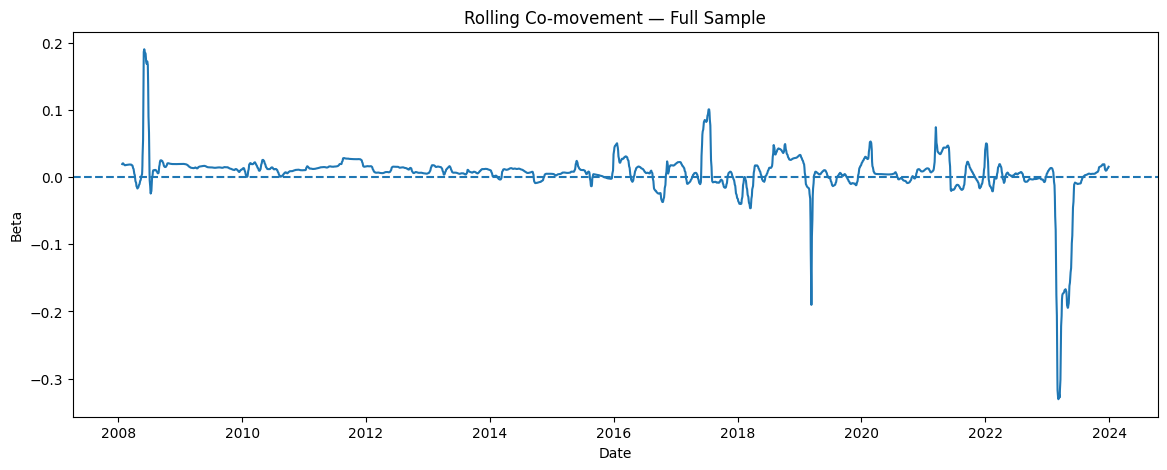

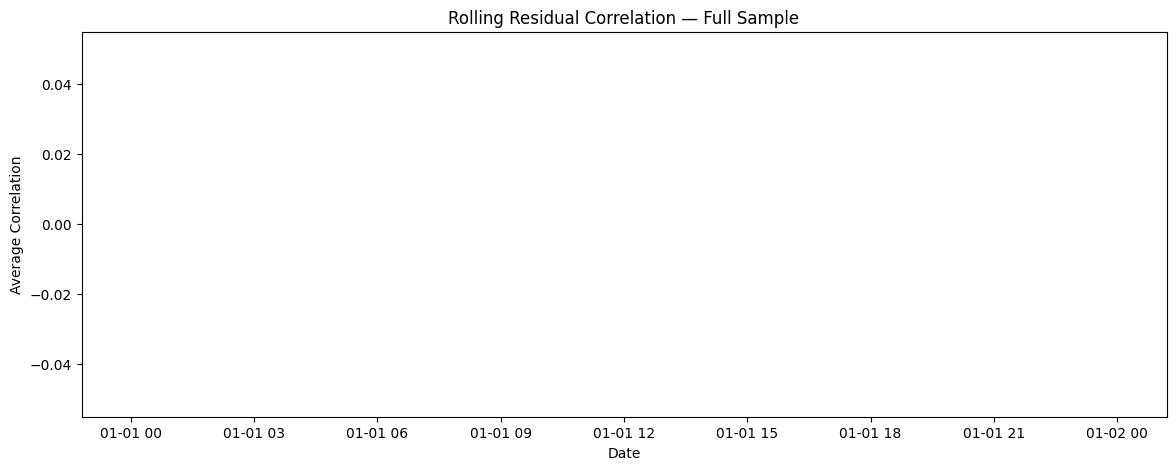

In [92]:
# =====================================================
# FULL SAMPLE — ROLLING CO-MOVEMENT
# =====================================================

rolling_beta_full = rolling_regression(

    reg1_full["idio_risk"],

    reg1_full["market_vol"]
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(14,5))

plt.plot(rolling_beta_full)

plt.title(

    "Rolling Co-movement — Full Sample"

)

plt.ylabel("Beta")

plt.xlabel("Date")

plt.axhline(0, linestyle='--')

plt.show()


# =====================================================
# FULL SAMPLE — DIVERSIFICATION BREAKDOWN
# =====================================================

rolling_corr_full = rolling_diversification_breakdown(

    residuals_full
)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(14,5))

plt.plot(rolling_corr_full)

plt.title(

    "Rolling Residual Correlation — Full Sample"

)

plt.ylabel("Average Correlation")

plt.xlabel("Date")

plt.show()

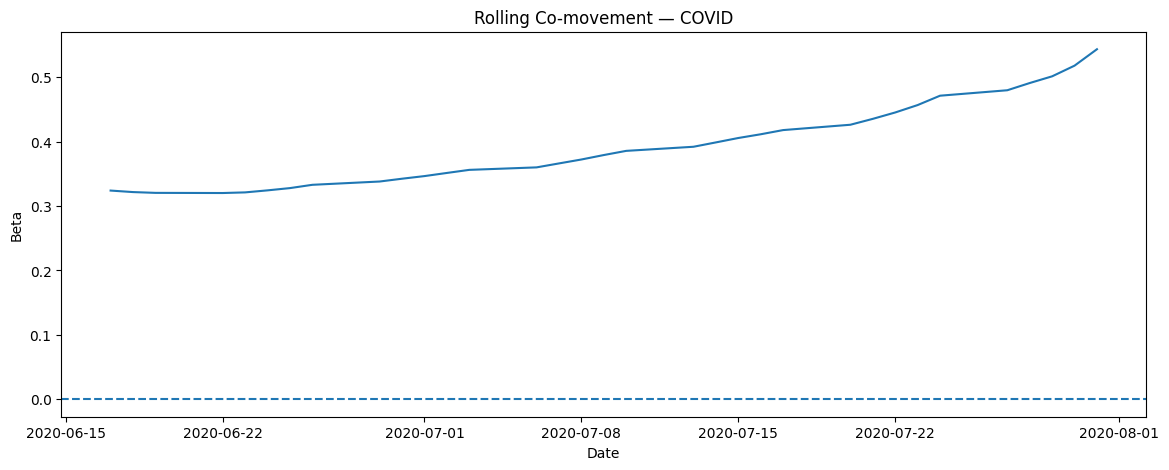

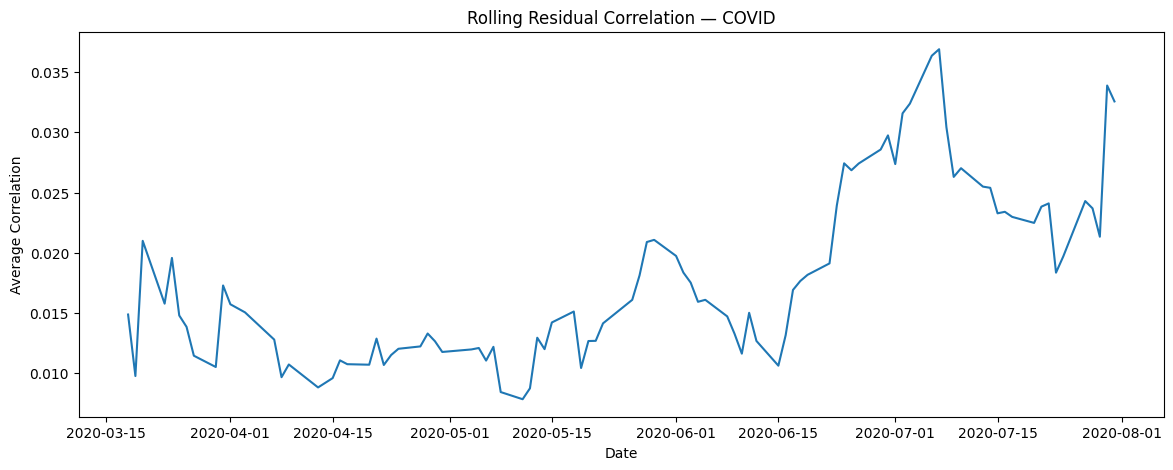

In [93]:
# =====================================================
# COVID — ROLLING CO-MOVEMENT
# =====================================================

rolling_beta_covid = rolling_regression(

    reg1_covid["idio_risk"],

    reg1_covid["market_vol"]
)

plt.figure(figsize=(14,5))

plt.plot(rolling_beta_covid)

plt.title(

    "Rolling Co-movement — COVID"

)

plt.ylabel("Beta")

plt.xlabel("Date")

plt.axhline(0, linestyle='--')

plt.show()


# =====================================================
# COVID — DIVERSIFICATION BREAKDOWN
# =====================================================

rolling_corr_covid = rolling_diversification_breakdown(

    residuals_covid
)

plt.figure(figsize=(14,5))

plt.plot(rolling_corr_covid)

plt.title(

    "Rolling Residual Correlation — COVID"

)

plt.ylabel("Average Correlation")

plt.xlabel("Date")

plt.show()

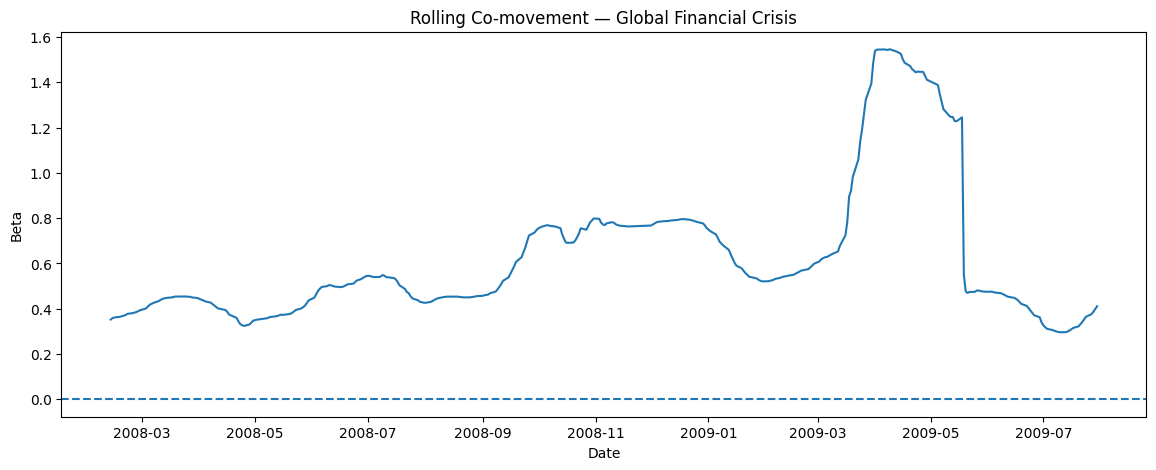

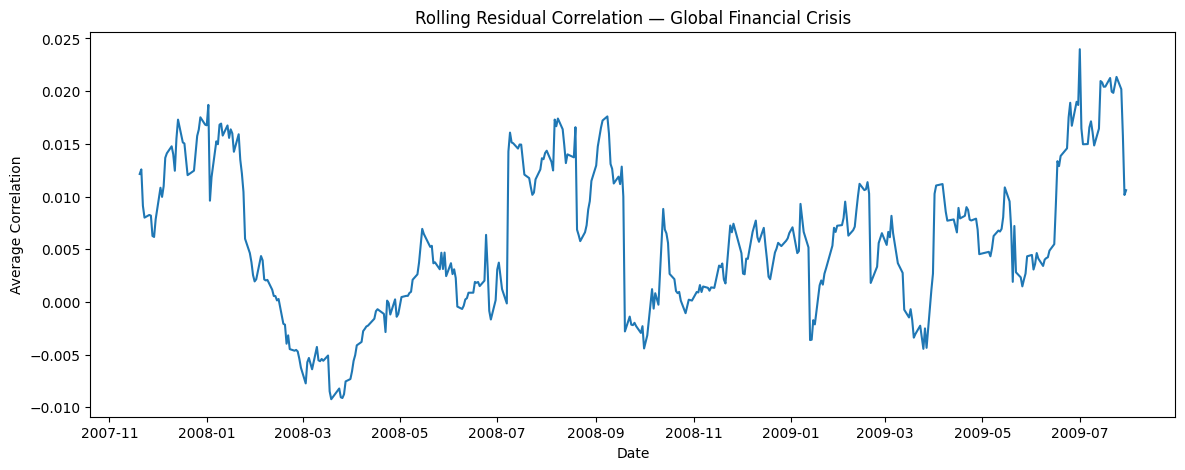

In [94]:
# =====================================================
# GFC — ROLLING CO-MOVEMENT
# =====================================================

rolling_beta_gfc = rolling_regression(

    reg1_gfc["idio_risk"],

    reg1_gfc["market_vol"]
)

plt.figure(figsize=(14,5))

plt.plot(rolling_beta_gfc)

plt.title(

    "Rolling Co-movement — Global Financial Crisis"

)

plt.ylabel("Beta")

plt.xlabel("Date")

plt.axhline(0, linestyle='--')

plt.show()


# =====================================================
# GFC — DIVERSIFICATION BREAKDOWN
# =====================================================

rolling_corr_gfc = rolling_diversification_breakdown(

    residuals_gfc
)

plt.figure(figsize=(14,5))

plt.plot(rolling_corr_gfc)

plt.title(

    "Rolling Residual Correlation — Global Financial Crisis"

)

plt.ylabel("Average Correlation")

plt.xlabel("Date")

plt.show()

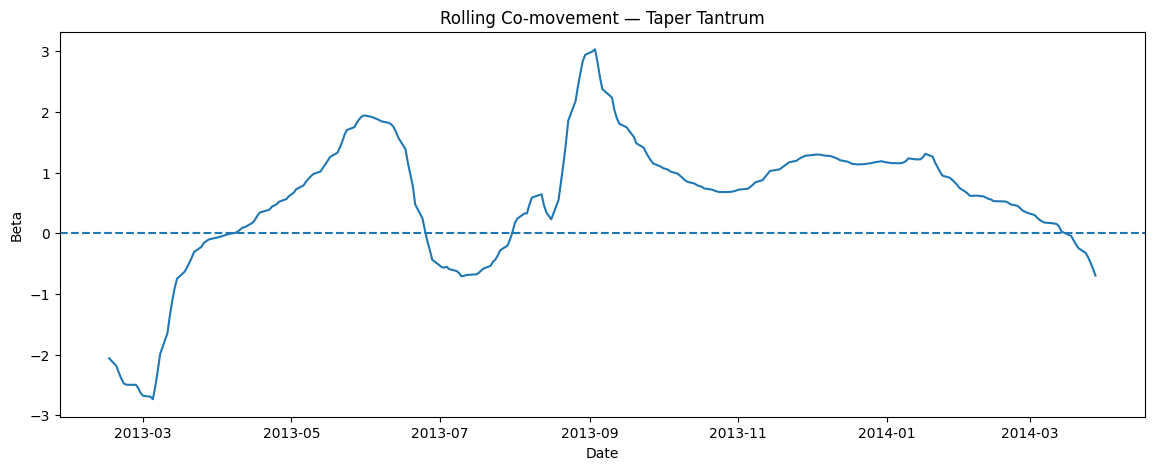

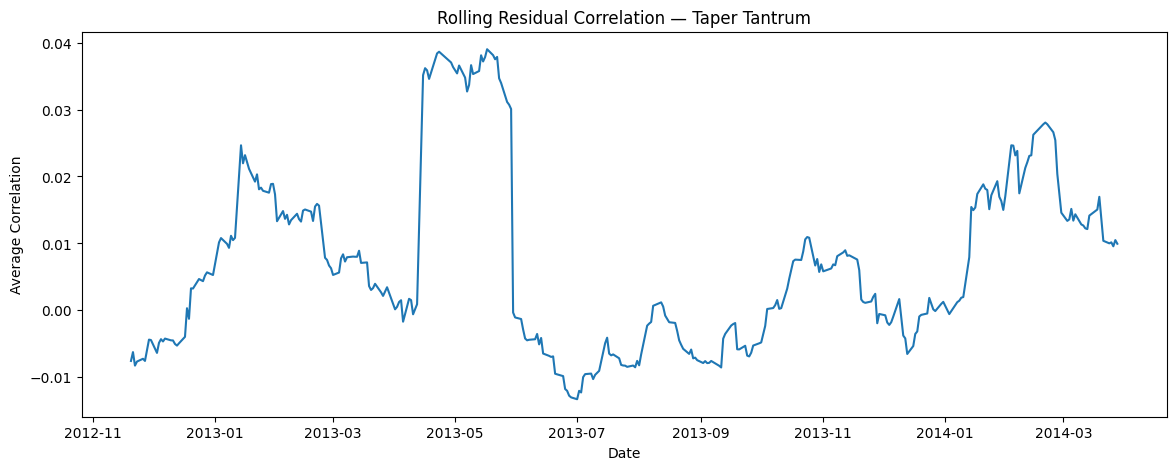

In [95]:
# =====================================================
# TAPER TANTRUM — ROLLING CO-MOVEMENT
# =====================================================

rolling_beta_taper = rolling_regression(

    reg1_taper["idio_risk"],

    reg1_taper["market_vol"]
)

plt.figure(figsize=(14,5))

plt.plot(rolling_beta_taper)

plt.title(

    "Rolling Co-movement — Taper Tantrum"

)

plt.ylabel("Beta")

plt.xlabel("Date")

plt.axhline(0, linestyle='--')

plt.show()


# =====================================================
# TAPER TANTRUM — DIVERSIFICATION BREAKDOWN
# =====================================================

rolling_corr_taper = rolling_diversification_breakdown(

    residuals_taper
)

plt.figure(figsize=(14,5))

plt.plot(rolling_corr_taper)

plt.title(

    "Rolling Residual Correlation — Taper Tantrum"

)

plt.ylabel("Average Correlation")

plt.xlabel("Date")

plt.show()

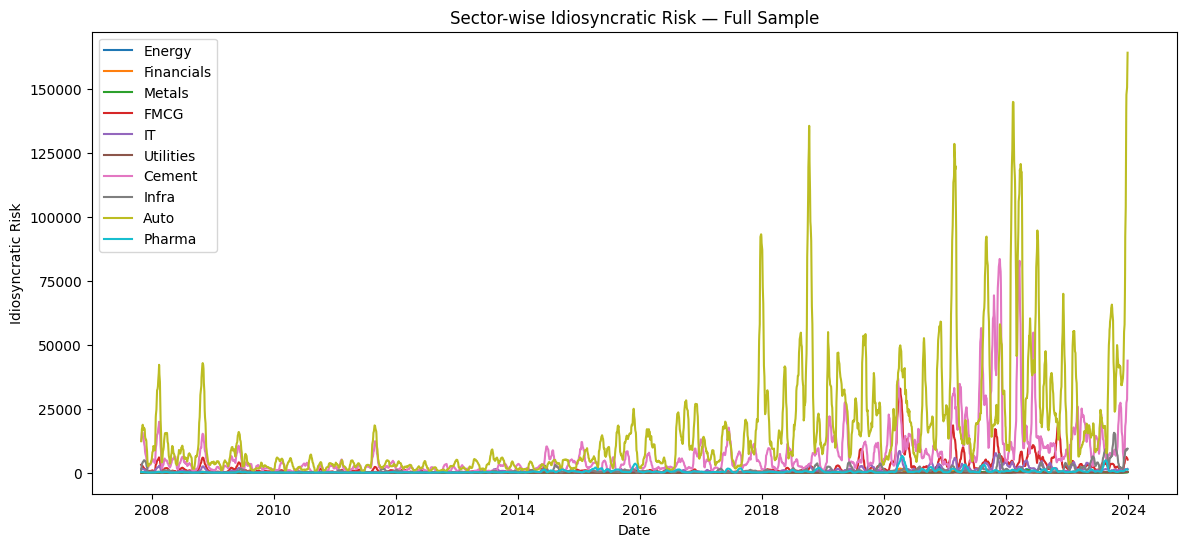

In [96]:
# =====================================================
# FULL SAMPLE — SECTOR-WISE IDIOSYNCRATIC RISK
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

for sector in sector_full.columns:

    plt.plot(

        sector_full.index,

        sector_full[sector],

        label=sector
    )

plt.title(

    "Sector-wise Idiosyncratic Risk — Full Sample"

)

plt.ylabel("Idiosyncratic Risk")

plt.xlabel("Date")

plt.legend()

plt.show()

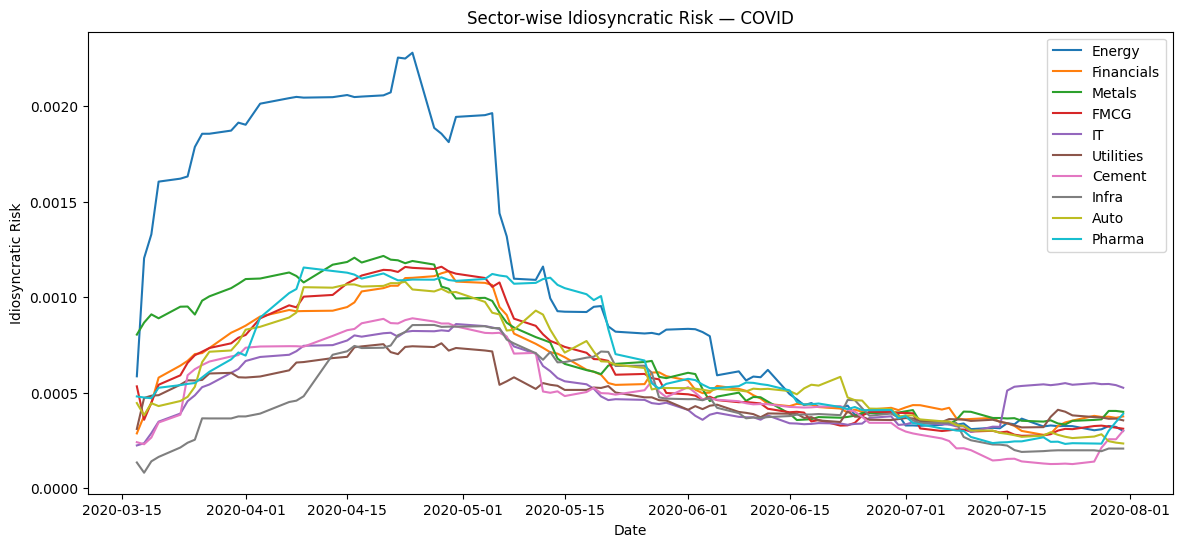

In [97]:
# =====================================================
# COVID — SECTOR-WISE IDIOSYNCRATIC RISK
# =====================================================

plt.figure(figsize=(14,6))

for sector in sector_covid.columns:

    plt.plot(

        sector_covid.index,

        sector_covid[sector],

        label=sector
    )

plt.title(

    "Sector-wise Idiosyncratic Risk — COVID"

)

plt.ylabel("Idiosyncratic Risk")

plt.xlabel("Date")

plt.legend()

plt.show()

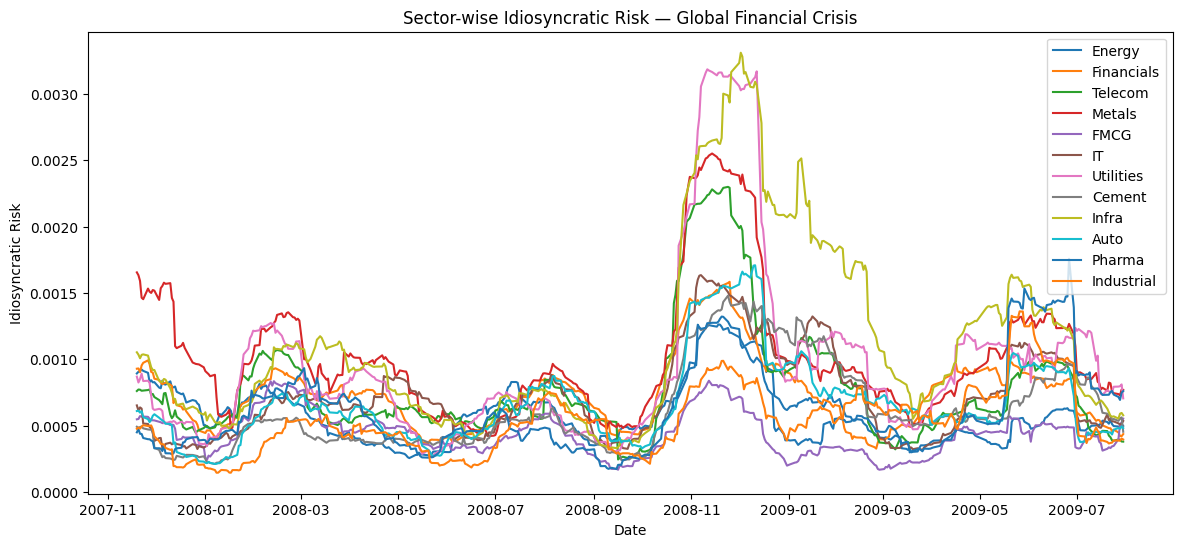

In [98]:
# =====================================================
# GLOBAL FINANCIAL CRISIS — SECTOR-WISE IDIOSYNCRATIC RISK
# =====================================================

plt.figure(figsize=(14,6))

for sector in sector_gfc.columns:

    plt.plot(

        sector_gfc.index,

        sector_gfc[sector],

        label=sector
    )

plt.title(

    "Sector-wise Idiosyncratic Risk — Global Financial Crisis"

)

plt.ylabel("Idiosyncratic Risk")

plt.xlabel("Date")

plt.legend()

plt.show()

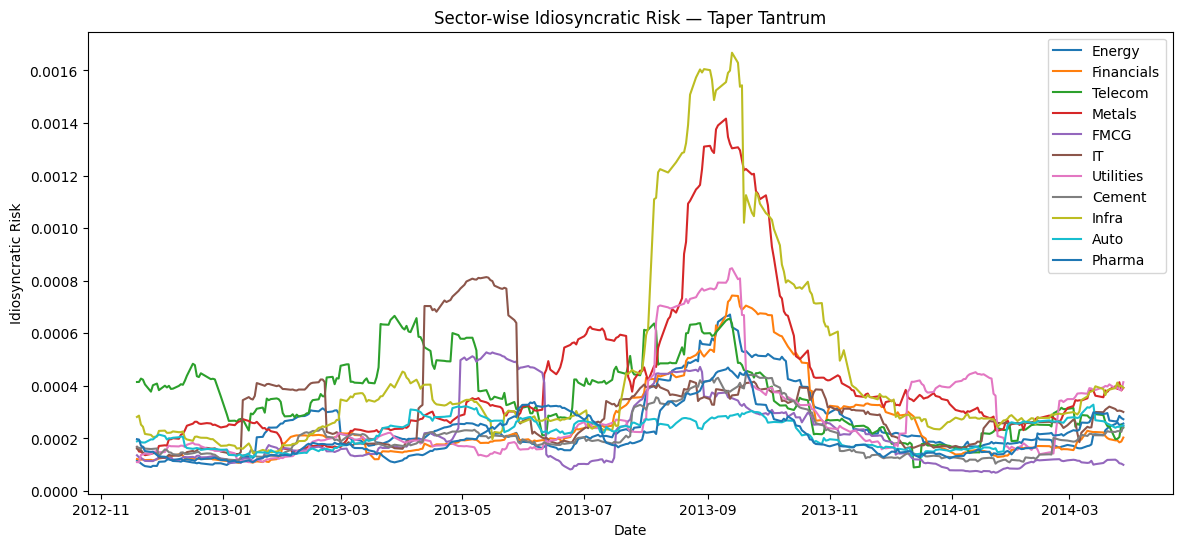

In [99]:
# =====================================================
# TAPER TANTRUM — SECTOR-WISE IDIOSYNCRATIC RISK
# =====================================================

plt.figure(figsize=(14,6))

for sector in sector_taper.columns:

    plt.plot(

        sector_taper.index,

        sector_taper[sector],

        label=sector
    )

plt.title(

    "Sector-wise Idiosyncratic Risk — Taper Tantrum"

)

plt.ylabel("Idiosyncratic Risk")

plt.xlabel("Date")

plt.legend()

plt.show()

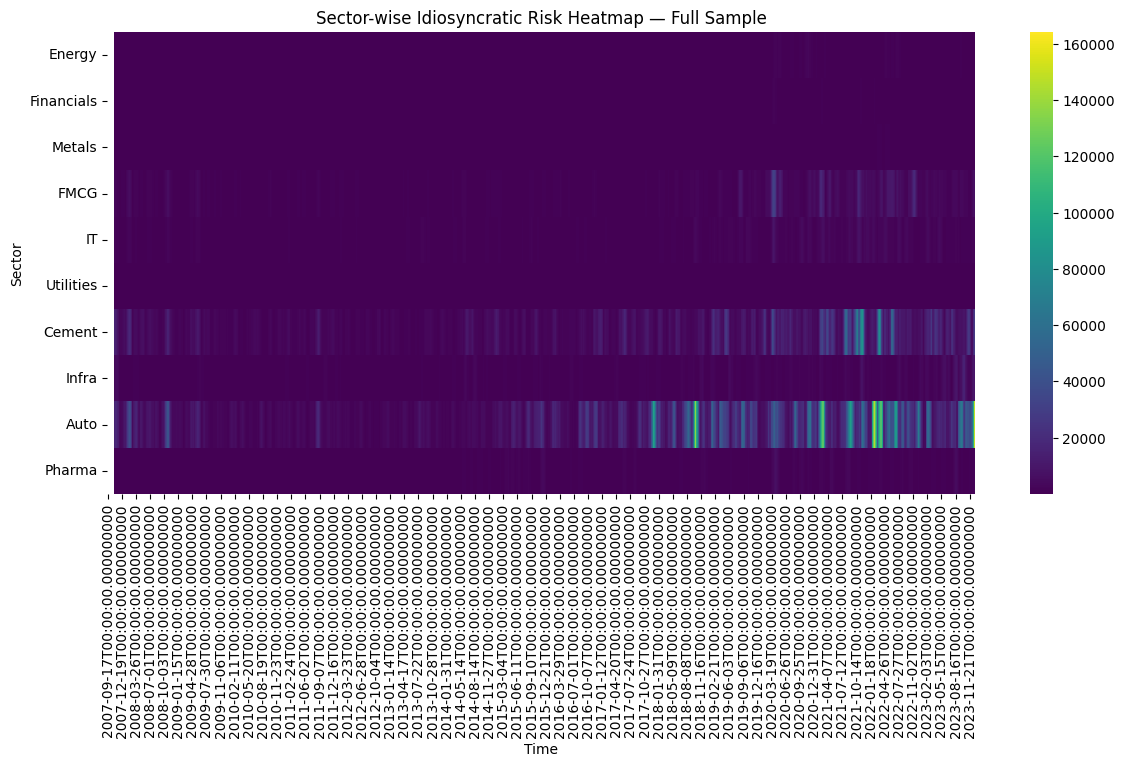

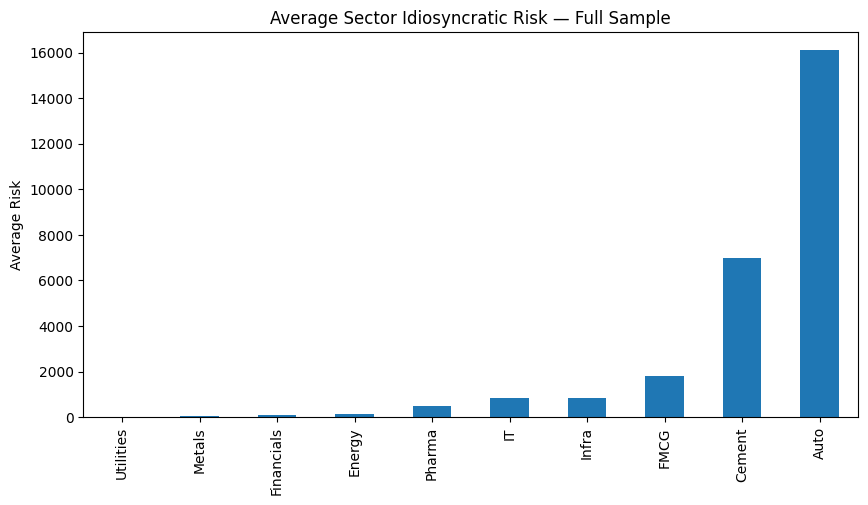

In [104]:
# =====================================================
# FULL SAMPLE — SECTOR HEATMAP
# =====================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.heatmap(

    sector_full.T,

    cmap="viridis"

)

plt.title(

    "Sector-wise Idiosyncratic Risk Heatmap — Full Sample"

)

plt.xlabel("Time")

plt.ylabel("Sector")

plt.show()


# =====================================================
# FULL SAMPLE — AVERAGE SECTOR RISK BAR CHART
# =====================================================

avg_sector_risk_full = sector_full.mean()

avg_sector_risk_full.sort_values().plot(

    kind='bar',

    figsize=(10,5)
)

plt.title(

    "Average Sector Idiosyncratic Risk — Full Sample"

)

plt.ylabel("Average Risk")

plt.show()

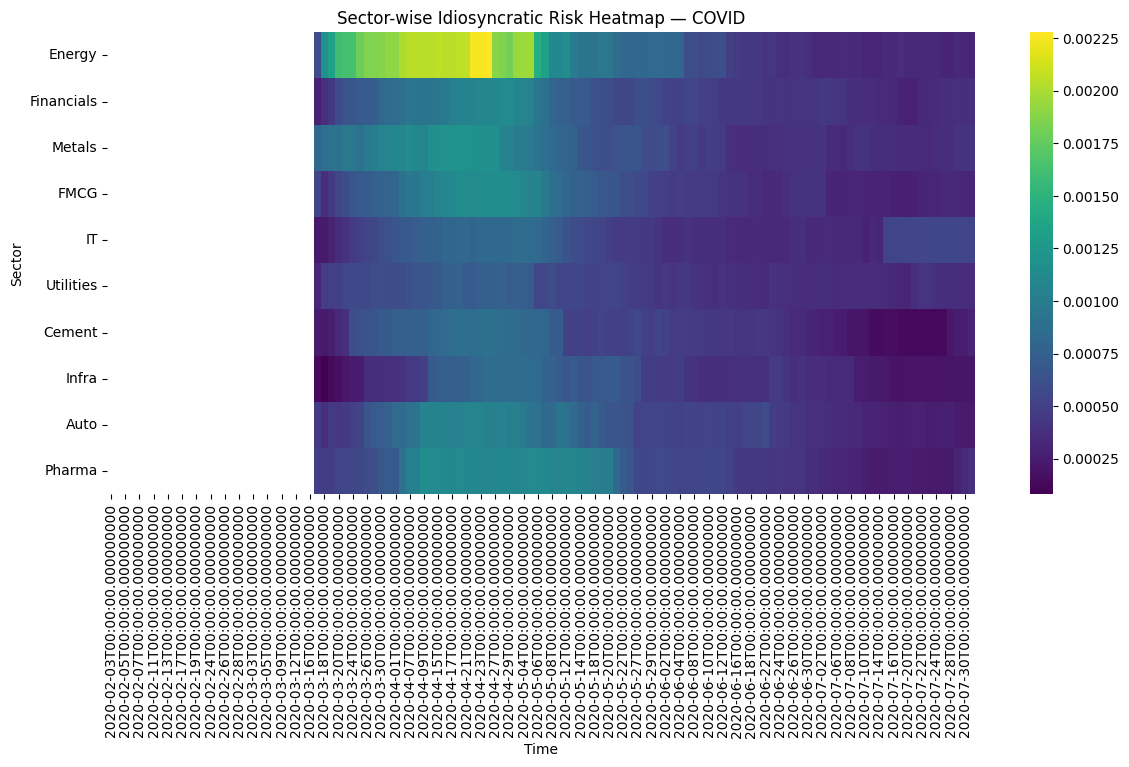

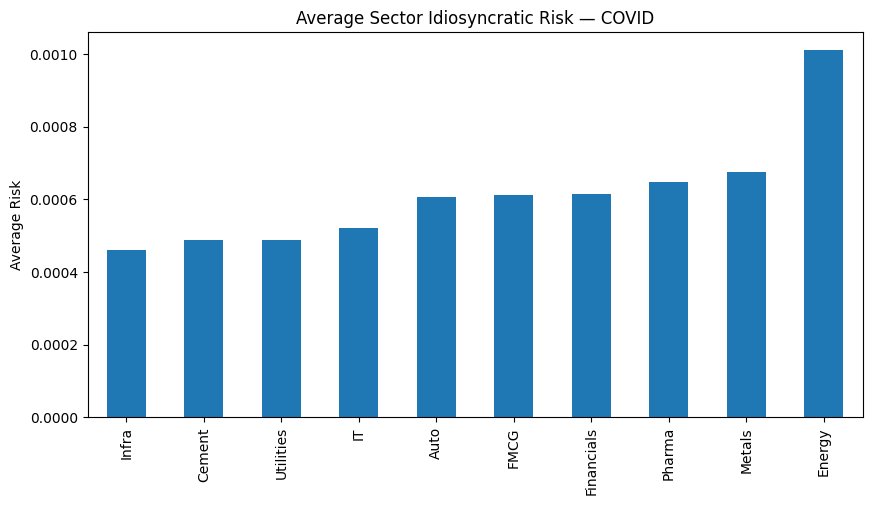

In [105]:
# =====================================================
# COVID — SECTOR HEATMAP
# =====================================================

plt.figure(figsize=(14,6))

sns.heatmap(

    sector_covid.T,

    cmap="viridis"

)

plt.title(

    "Sector-wise Idiosyncratic Risk Heatmap — COVID"

)

plt.xlabel("Time")

plt.ylabel("Sector")

plt.show()


# =====================================================
# COVID — AVERAGE SECTOR RISK BAR CHART
# =====================================================

avg_sector_risk_covid = sector_covid.mean()

avg_sector_risk_covid.sort_values().plot(

    kind='bar',

    figsize=(10,5)
)

plt.title(

    "Average Sector Idiosyncratic Risk — COVID"

)

plt.ylabel("Average Risk")

plt.show()

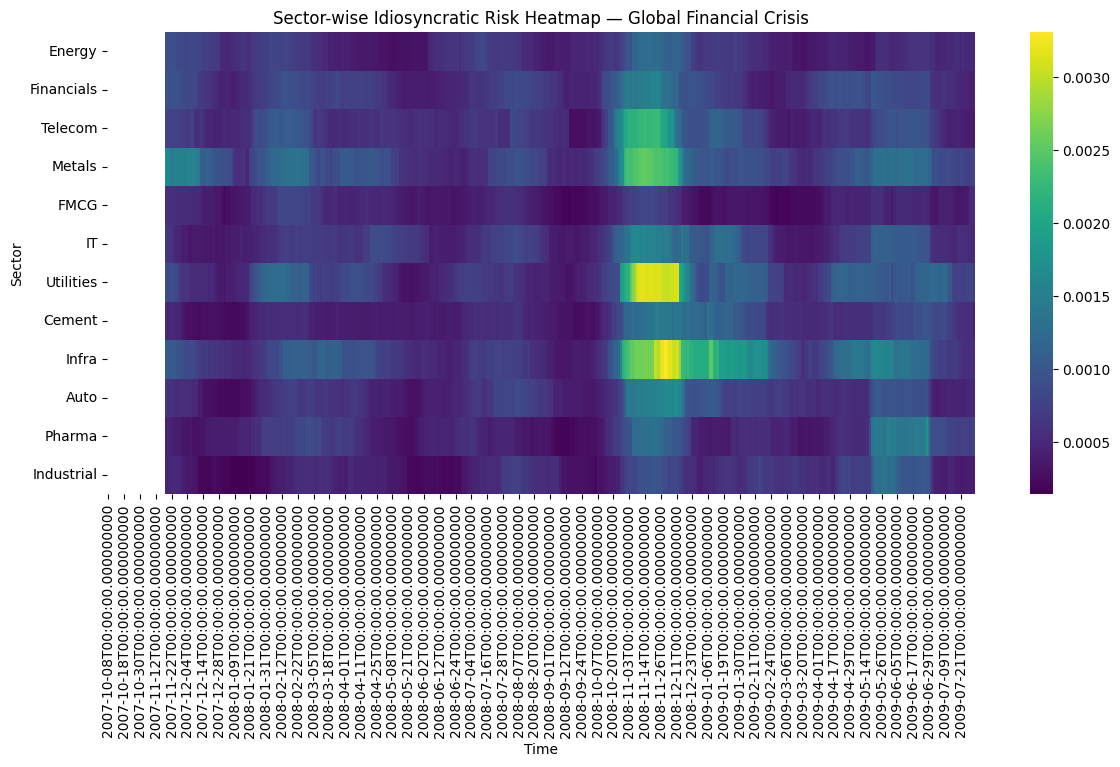

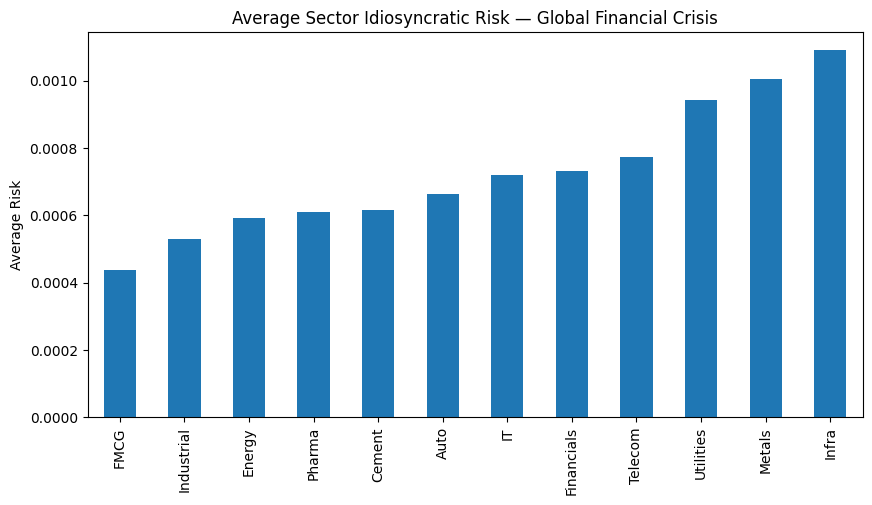

In [106]:
# =====================================================
# GLOBAL FINANCIAL CRISIS — SECTOR HEATMAP
# =====================================================

plt.figure(figsize=(14,6))

sns.heatmap(

    sector_gfc.T,

    cmap="viridis"

)

plt.title(

    "Sector-wise Idiosyncratic Risk Heatmap — Global Financial Crisis"

)

plt.xlabel("Time")

plt.ylabel("Sector")

plt.show()


# =====================================================
# GLOBAL FINANCIAL CRISIS — AVERAGE SECTOR RISK BAR CHART
# =====================================================

avg_sector_risk_gfc = sector_gfc.mean()

avg_sector_risk_gfc.sort_values().plot(

    kind='bar',

    figsize=(10,5)
)

plt.title(

    "Average Sector Idiosyncratic Risk — Global Financial Crisis"

)

plt.ylabel("Average Risk")

plt.show()

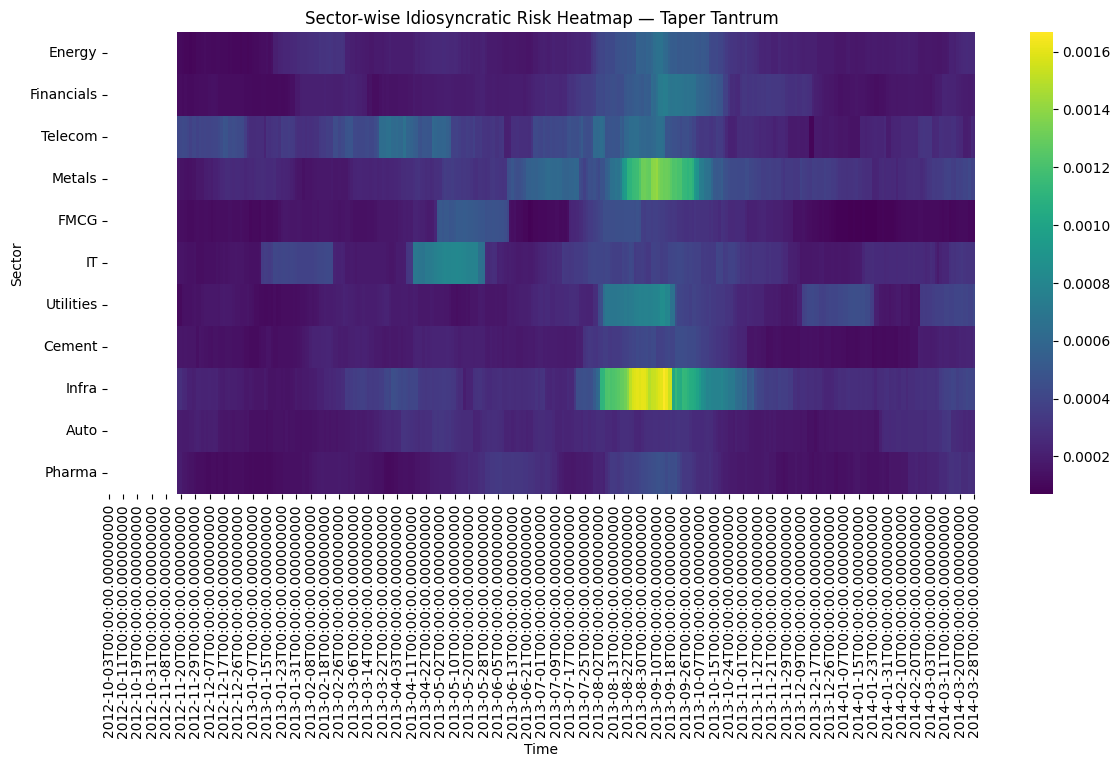

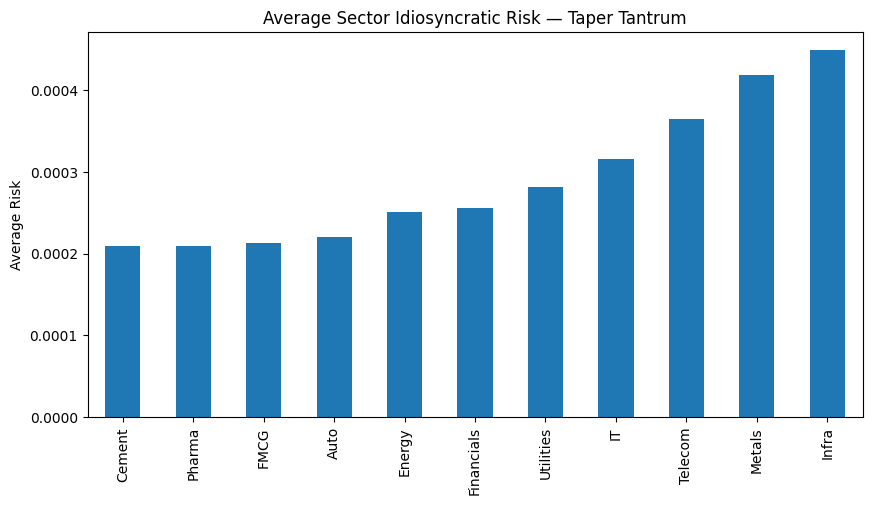

In [107]:
# =====================================================
# TAPER TANTRUM — SECTOR HEATMAP
# =====================================================

plt.figure(figsize=(14,6))

sns.heatmap(

    sector_taper.T,

    cmap="viridis"

)

plt.title(

    "Sector-wise Idiosyncratic Risk Heatmap — Taper Tantrum"

)

plt.xlabel("Time")

plt.ylabel("Sector")

plt.show()


# =====================================================
# TAPER TANTRUM — AVERAGE SECTOR RISK BAR CHART
# =====================================================

avg_sector_risk_taper = sector_taper.mean()

avg_sector_risk_taper.sort_values().plot(

    kind='bar',

    figsize=(10,5)
)

plt.title(

    "Average Sector Idiosyncratic Risk — Taper Tantrum"

)

plt.ylabel("Average Risk")

plt.show()